# Mean-inference checks

A1-style checks for **$P_\mathrm{gg}+P_\mathrm{gm}$** at the new fiducial **$k_{\mathrm{p,max}}=0.35$, $k_{\mathrm{pgm,max}}=0.25$**: how the CV-mean posterior (and, where available, the full A1 comparison) changes with **$k_{\mathrm{pgm,max}}$** (Pk fixed) and **$n_\mathrm{train}$**.

**A1 reminder:** colored = inference on the mean data vector; thin grey = random individual posteriors; brown = recentered pooled indiv.; black = distribution of posterior means.

**Masks:** joined `_kp0.35_kpgm*` (loose PGM = `_kp0.35`).

**On disk notes:**
- Trained networks exist across the $k_{\mathrm{pgm}}$ grid at fixed $k_\mathrm{p}=0.35$.
- CV-mean samples exist for most of that grid; CV-sample (indiv.) jobs may still be running — full A1 needs those.
- $n_\mathrm{train}$ variants for this fiducial are not trained yet (only $n_\mathrm{train}=10000$).


In [1]:
import sys
import pickle
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm

import paths
import plotter
import data_loader
import generate_params as genp
import utils_plot
import utils_inference

%load_ext autoreload
%autoreload 2


In [2]:
# --- Config (new fiducial: kp=0.35, kpgm=0.25) ---
bx = 32
STATISTICS_ROW = ["pk", "pgm"]
KP_FIXED = 0.35
TAG_MASK_FID = "_kp0.35_kpgm0.25"
# Legacy loose Pk (implicit k_p,max ≈ 0.4) + k_pgm,max=0.25 — has indiv samples
TAG_MASK_KP04 = "_kpgm0.25"
COLOR_FID = "#6BB756"
N_ENSEMBLE_K = 3
COLORS_ENSEMBLE_MEMBERS = ["#6BB756", "#3D8B6E", "#1F5C4D"]  # best, nbest1, nbest2
COLOR_ENSEMBLE_MIX = "#8B5A2B"  # equal-weight mixture
COLOR_OLD_FID = "#2F6B2F"       # legacy kp≈0.4 mean-inf (dark green)
COLOR_NEW_FID = COLOR_FID       # new kp=0.35 mean-inf (same green as A1)
# both recentered pooled use COLOR_RECENTERED (brown); distinguished by linestyle

n_train_fid = 10000
TAG_INF_BEST_SUFFIX = "_best-rand30"

data_mode = "muchisimocks"
TAG_PARAMS_TRAIN = "_p5_n10000"
TAG_BIASPARAMS_TRAIN = "_biasnoisenest_p9_n320000"
TAG_NOISE_TRAIN = "_noise_unit_p5_n10000"
tag_reparam = "_rp"

TAG_PARAMS_TEST_FIXED = "_shame_p0_n1000"
TAG_BIASPARAMS_TEST_FIXED = "_biasshame_noisebest_p0_n1"
TAG_NOISE_TEST_FIXED = "_noise_unit_shame_p0_n1000"
TAG_DATAGEN_TEST_MEAN = "_mean"

# PGM kmax grid with Pk fixed at kp=0.35 (trained on disk)
# Joined masks: _kp0.35_kpgm* ; loose PGM = _kp0.35
TAGS_KMAX_KPGM = [
    "_kp0.35_kpgm0.1",
    "_kp0.35_kpgm0.15",
    "_kp0.35_kpgm0.2",
    "_kp0.35_kpgm0.25",
    "_kp0.35_kpgm0.27",
    "_kp0.35_kpgm0.3",
    "_kp0.35_kpgm0.32",
    "_kp0.35_kpgm0.35",
    "_kp0.35_kpgm0.37",
    "_kp0.35",  # loose PGM ≈ 0.4
]
N_TRAIN_ARR = [500, 1000, 2000, 4000, 6000, 8000, 10000]

param_names_key, param_names_key_rp = utils_plot.get_param_names_key()
PARAM_NAMES_ZOOM = list(param_names_key)
_, _, _param_vary_train = utils_plot.load_training_params(
    TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
)
# Inferred physical params; drop cosmo not in the posterior.
_COSMO_NOT_IN_POSTERIOR = {"hubble", "omega_baryon", "ns"}
_BIAS_PARAMS = {"b1", "b2", "bs2", "bl"}
_NOISE_PARAMS = {"An_homog", "An_b1", "An_b2", "An_bs2", "An_bl"}
PARAM_NAMES_ALL = [pn for pn in _param_vary_train if pn not in _COSMO_NOT_IN_POSTERIOR]
PARAM_NAMES_COSMO_BIAS = [pn for pn in PARAM_NAMES_ALL if pn not in _NOISE_PARAMS]
PARAM_NAMES_COSMO_NOISE = [pn for pn in PARAM_NAMES_ALL if pn not in _BIAS_PARAMS]
idx_obs = 0

ANOISE_OPTION = "Anmult"
extents = {**genp.get_bounds("cosmo"), **genp.get_bounds("bias")}
extents_contours = extents.copy()
extents_contours["b1"] = [0.0, 1.0]
extents_all = {
    **genp.get_bounds("cosmo"),
    **genp.get_bounds("bias"),
    **genp.get_bounds("Anoise", anoise_option=ANOISE_OPTION),
}
extents_all["b1"] = extents_contours["b1"]
# Full prior edges (no tightened b1 window)
extents_prior = {
    **genp.get_bounds("cosmo"),
    **genp.get_bounds("bias"),
    **genp.get_bounds("Anoise", anoise_option=ANOISE_OPTION),
}

FIGSIZE_CORNER = (5.5, 5.5)
FIGSIZE_ALL_PARAMS = (9, 9)
FONTSIZE_LEGEND = 10
LOC_LEGEND = (1.02, 0.98)
dir_sbi = paths.DIR_RESULTS / "results_sbi"

FIG_DIR = REPO_ROOT / "figures" / "2026-09-08_mean_inf_checks"
OVERWRITE_FIGURES = True
FIG_EXT = "png"

CACHE_DIR = REPO_ROOT / "figures" / "paper_figures_cache"
OVERWRITE_CACHE = False

# A1 style
COLOR_INDIV_MEANS = "black"
COLOR_RECENTERED = "#8B5A2B"
COLOR_RAND = "#8C8C8C"
LW_MEAN = 1.2
LW_RECENTERED = 1.6
LW_RAND = 0.35
N_RAND = 10
K_PER_OBS = 500
SMOOTH_MEANS = 0
BINS_MEANS = 12
KDE_MEANS = True
EXTENTS_A = {
    "omega_cold": [0.25, 0.37],
    "sigma8_cold": [0.75, 0.88],
    "b1": [0.35, 0.60],
}
# Wider window for Pgg and Pgg+Bggg (no Pgm; broader posteriors)
EXTENTS_A_WIDE = {
    "omega_cold": [0.23, 0.40],
    "sigma8_cold": [0.70, 0.90],
    "b1": [0.20, 0.80],
}
LABEL_MEAN = "inference on mean data vector"
LABEL_INDIV = "distribution of means of indiv. posteriors"
LABEL_MEAN_OF_MEANS = "mean of individual posteriors"
LABEL_RECENTERED = "recentered, pooled indiv. posteriors"
LABEL_RAND = f"{N_RAND} random indiv. posteriors"

STAT_LABELS_SHORT = {
    "pk": r"$P_\mathrm{gg}$",
    "bispec": r"$B_\mathrm{ggg}$",
    "pgm": r"$P_\mathrm{gm}$",
}


def get_stat_label_short(statistics):
    order = {"pk": 0, "pgm": 1, "bispec": 2}
    stats = sorted(statistics, key=lambda s: order.get(s, 99))
    return " + ".join(STAT_LABELS_SHORT[s] for s in stats)


def kmax_label_from_mask(tag_mask):
    """Numeric k_pgm,max from joined mask (_kp0.35_kpgm0.25 or _kp0.35)."""
    if "_kpgm" in tag_mask:
        return float(tag_mask.split("_kpgm", 1)[1])
    # Pk-only / loose PGM cut
    return 0.4


def kmax_legend_label(tag_mask):
    km = kmax_label_from_mask(tag_mask)
    loose = " (loose PGM)" if "_kpgm" not in tag_mask else ""
    return rf"$k_{{\mathrm{{pgm,max}}}}={km}${loose}"


def sequential_colors(values, cmap_name="viridis"):
    vals = list(values)
    cmap = cm.get_cmap(cmap_name)
    if len(vals) == 1:
        return {vals[0]: cmap(0.55)}
    vmin, vmax = min(vals), max(vals)
    return {
        v: cmap(0.15 + 0.75 * (v - vmin) / (vmax - vmin))
        for v in vals
    }


def load_or_build(name, builder, *, overwrite=None):
    if overwrite is None:
        overwrite = OVERWRITE_CACHE
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    path = CACHE_DIR / f"{name}.pkl"
    if path.is_file() and not overwrite:
        print(f"Loaded cache: {path}")
        with open(path, "rb") as f:
            return pickle.load(f)
    obj = builder()
    with open(path, "wb") as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Wrote cache: {path}")
    return obj


def save_figure(fig, name, ext=FIG_EXT):
    filename = f"{name}.{ext}"
    path = FIG_DIR / filename
    if path.exists() and not OVERWRITE_FIGURES:
        print(f"Skipping save (exists, overwrite=False): {filename}")
        return
    fig.canvas.draw_idle()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, bbox_inches="tight", facecolor="white", edgecolor="none")
    print(f"Saved: {path}")


def sample_fn(tag_inf, tag_test):
    return dir_sbi / f"sbi{tag_inf}" / f"samples_test{tag_test}_pred.npy"


def build_tag_inf(tag_mask, n_train, nbest=None):
    tags_inf, _, _, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN,
        statistics_arr=[STATISTICS_ROW],
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=[tag_mask],
    )
    tag = tags_inf[0] + TAG_INF_BEST_SUFFIX
    if nbest is not None and int(nbest) > 0:
        tag = f"{tag}_nbest{int(nbest)}"
    return tag


def build_tag_test(tag_mask, *, mean=True):
    tag_stats = f'_{"_".join(STATISTICS_ROW)}'
    return utils_plot.setup_test_tags(
        data_mode=data_mode,
        tag_params_test=TAG_PARAMS_TEST_FIXED,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED,
        tag_stats_arr=[tag_stats],
        tag_noise_test=TAG_NOISE_TEST_FIXED,
        tag_datagen_test=TAG_DATAGEN_TEST_MEAN if mean else "",
        tags_mask_test=[tag_mask],
    )[0]


def theta_show_fixed(param_names=None):
    """True params for fixed-cosmo shame mean test (physical coords)."""
    if param_names is None:
        param_names = PARAM_NAMES_ZOOM
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    theta = data_loader.load_theta_test(
        TAG_PARAMS_TEST_FIXED,
        TAG_BIASPARAMS_TEST_FIXED,
        cosmo_param_names_vary=cosmo_vary,
        bias_param_names_vary=bias_vary,
    )
    theta_obs = theta[idx_obs] if theta.ndim == 2 else theta
    idxs = [param_vary.index(pn) for pn in param_names]
    return theta_obs[idxs]


THETA_SHOW = theta_show_fixed(PARAM_NAMES_ZOOM)
THETA_SHOW_COSMO_BIAS = theta_show_fixed(PARAM_NAMES_COSMO_BIAS)
THETA_SHOW_COSMO_NOISE = theta_show_fixed(PARAM_NAMES_COSMO_NOISE)
print("theta_show (zoom):", dict(zip(PARAM_NAMES_ZOOM, THETA_SHOW)))
print("theta_show (cosmo+bias):", dict(zip(PARAM_NAMES_COSMO_BIAS, THETA_SHOW_COSMO_BIAS)))
print("theta_show (cosmo+noise):", dict(zip(PARAM_NAMES_COSMO_NOISE, THETA_SHOW_COSMO_NOISE)))
print("FIG_DIR:", FIG_DIR)


theta_show (zoom): {'omega_cold': 0.3088999999999999, 'sigma8_cold': 0.8159, 'b1': 0.47410742}
theta_show (cosmo+bias): {'omega_cold': 0.3088999999999999, 'sigma8_cold': 0.8159, 'b1': 0.47410742, 'b2': 0.12701492, 'bs2': -0.33881766, 'bl': -0.82443643}
theta_show (cosmo+noise): {'omega_cold': 0.3088999999999999, 'sigma8_cold': 0.8159, 'An_homog': 2.346482608623328, 'An_b1': -1.3433619456637138, 'An_b2': -0.226130277108882, 'An_bs2': 0.5266325796844749, 'An_bl': 1.6813773681515105}
FIG_DIR: /home/kstoreyf/muchisimocks/figures/2026-09-08_mean_inf_checks


In [3]:
def cache_name_for(statistics_row, tag_mask, n_train, param_names=None, nbest=None):
    key = "_".join(statistics_row)
    mask_key = tag_mask.lstrip("_") if tag_mask else "loose"
    if param_names is None or list(param_names) == list(PARAM_NAMES_ZOOM):
        pkey = "zoom"
    elif list(param_names) == list(PARAM_NAMES_COSMO_BIAS):
        pkey = "cosmo_bias"
    elif list(param_names) == list(PARAM_NAMES_COSMO_NOISE):
        pkey = "cosmo_noise"
    elif list(param_names) == list(PARAM_NAMES_ALL):
        pkey = "all"
    else:
        pkey = f"n{len(param_names)}"
    nbest_key = "" if not nbest else f"_nbest{int(nbest)}"
    return f"mean_inf_a1_recentered_{key}_{mask_key}_ntrain{n_train}_k{K_PER_OBS}_{pkey}{nbest_key}"



def _place_a1_legend(fig, *, loc="upper center", fontsize=None):
    """Move ChainConsumer legend into the empty upper region of the triangle."""
    if fig is None:
        return
    if fontsize is None:
        fontsize = FONTSIZE_LEGEND
    ax_leg = next((ax for ax in fig.axes if ax.get_legend() is not None), None)
    if ax_leg is None:
        return
    old = ax_leg.get_legend()
    handles = old.legend_handles
    labels = [t.get_text() for t in old.get_texts()]
    old.remove()
    # Drop underscore-prefixed dummy labels (e.g. _rand1)
    keep = [(h, lab) for h, lab in zip(handles, labels) if lab and not lab.startswith("_")]
    if not keep:
        return
    handles, labels = zip(*keep)
    # Sit in the blank upper-triangle whitespace (below title, centered horizontally
    # in that empty region — slightly right of figure center).
    fig.legend(
        handles, labels,
        loc=loc,
        bbox_to_anchor=(0.72, 0.86),
        bbox_transform=fig.transFigure,
        fontsize=fontsize,
        frameon=False,
        labelcolor="black",
        handlelength=1.4,
        handletextpad=0.35,
        borderaxespad=0.0,
        labelspacing=0.35,
        ncol=1,
    )


def _overlay_mean_of_means(
    fig, theta_bar, *, color=None, ls="--", lw=0.5, ms=3.5,
    label=None, add_legend=True, legend_bbox_to_anchor=(1.5, 0.8),
):
    """Mark θ̄: dashed vertical line on 1D diagonal only; circle on 2D panels only.

    ChainConsumer Truth draws crosshairs on 2D, so we overlay manually instead.
    Assumes a lower-triangle corner: axis (i, j) has x=param j, y=param i.
    Optionally appends a combined dashed-line+dot handle to the existing legend.
    """
    from matplotlib.lines import Line2D

    if fig is None:
        return
    if color is None:
        color = COLOR_RECENTERED
    if label is None:
        label = LABEL_MEAN_OF_MEANS
    theta_bar = np.asarray(theta_bar, dtype=float).reshape(-1)
    axes_grid = {}
    for ax in fig.axes:
        spec = ax.get_subplotspec()
        if spec is None:
            continue
        r0, r1 = spec.rowspan.start, spec.rowspan.stop
        c0, c1 = spec.colspan.start, spec.colspan.stop
        if (r1 - r0) != 1 or (c1 - c0) != 1:
            continue
        axes_grid[(r0, c0)] = ax
    if not axes_grid:
        return
    n_ax = max(r for r, _ in axes_grid) + 1
    for i in range(n_ax):
        for j in range(i + 1):
            ax = axes_grid.get((i, j))
            if ax is None or j >= len(theta_bar) or i >= len(theta_bar):
                continue
            if i == j:
                ax.axvline(theta_bar[j], color=color, ls=ls, lw=lw, zorder=100)
            else:
                ax.plot(
                    theta_bar[j], theta_bar[i],
                    linestyle="none", marker="o", markersize=ms,
                    color=color, markeredgecolor=color, zorder=100,
                )

    if not add_legend:
        return
    handle = Line2D(
        [0], [0],
        color=color, ls=ls, lw=lw,
        marker="o", markersize=ms,
        markerfacecolor=color, markeredgecolor=color,
    )
    ax_leg = next((ax for ax in fig.axes if ax.get_legend() is not None), None)
    if ax_leg is None:
        fig.legend(
            [handle], [label],
            loc="upper left", frameon=False, fontsize=FONTSIZE_LEGEND,
        )
        return
    old = ax_leg.get_legend()
    handles = list(old.legend_handles) + [handle]
    labels = [t.get_text() for t in old.get_texts()] + [label]
    keep = [(h, lab) for h, lab in zip(handles, labels) if lab and not lab.startswith("_")]
    if not keep:
        return
    handles, labels = zip(*keep)
    # Rebuild with the known A1 axes-fraction anchor — do NOT reuse
    # get_bbox_to_anchor() display coords (that balloons the figure to >2^16 px).
    old.remove()
    leg_kwargs = dict(
        loc="upper left",
        fontsize=FONTSIZE_LEGEND,
        frameon=False,
    )
    if legend_bbox_to_anchor is not None:
        leg_kwargs["bbox_to_anchor"] = legend_bbox_to_anchor
    ax_leg.legend(handles, labels, **leg_kwargs)


def plot_a1_variant(
    tag_masks_row=TAG_MASK_FID,
    n_train=n_train_fid,
    color_mean=COLOR_FID,
    save_name=None,
    extents=None,
    title=None,
    param_names=None,
    theta_obs_true=None,
    figsize=None,
    plot_indiv_means=True,
    mark_mean_of_means=False,
):
    """Mean-of-stats + thin grey indiv. + brown recentered pooled (+ black means).

    mark_mean_of_means: if True, mark mean(θ̂) (the recentering center) as a
    brown dashed vertical line on 1D panels and a brown circle on 2D panels
    (same color as recentered pooled; not ChainConsumer Truth, which draws crosshairs).
    """
    if param_names is None:
        param_names = list(PARAM_NAMES_ZOOM)
    else:
        param_names = list(param_names)
    if theta_obs_true is None:
        theta_obs_true = (
            THETA_SHOW if param_names == list(PARAM_NAMES_ZOOM)
            else theta_show_fixed(param_names)
        )
    if extents is None:
        extents = EXTENTS_A if param_names == list(PARAM_NAMES_ZOOM) else extents_prior
    if figsize is None:
        figsize = (
            FIGSIZE_CORNER if param_names == list(PARAM_NAMES_ZOOM)
            else FIGSIZE_ALL_PARAMS
        )

    tag_inf = build_tag_inf(tag_masks_row, n_train)
    tag_test_mean = build_tag_test(tag_masks_row, mean=True)
    tag_test_sample = build_tag_test(tag_masks_row, mean=False)

    fn_sample = sample_fn(tag_inf, tag_test_sample)
    fn_mean = sample_fn(tag_inf, tag_test_mean)
    if not fn_mean.exists():
        print(f"MISSING mean samples: {fn_mean}")
        return
    if not fn_sample.exists():
        print(f"MISSING indiv samples (cannot make full A1): {fn_sample}")
        print("Falling back to mean-only contour.")
        plot_mean_only(
            tag_masks_row=tag_masks_row,
            n_train=n_train,
            color_mean=color_mean,
            save_name=save_name,
            extents=extents,
            title=title,
            param_names=param_names,
            theta_obs_true=theta_obs_true,
            figsize=figsize,
        )
        return

    print(f"{get_stat_label_short(STATISTICS_ROW)}: indiv = {fn_sample}")
    print(f"  mean = {fn_mean}")

    def _build_recentered_bundle():
        samples_arr = np.load(fn_sample)
        param_names_samples = np.loadtxt(
            dir_sbi / f"sbi{tag_inf}" / "param_names.txt", dtype=str,
        )
        samples_u, names_u = utils_inference.unreparameterize_theta(
            samples_arr, list(param_names_samples), strict=False,
        )
        names_u = list(names_u)
        names_plot = [pn for pn in param_names if pn in names_u]
        if not names_plot:
            raise ValueError(
                f"None of {param_names} found in unreparam names {names_u}"
            )
        i_sel = [names_u.index(pn) for pn in names_plot]
        samples_sel = samples_u[:, :, i_sel]
        theta_hat = np.nanmean(samples_sel, axis=0)
        finite_obs = np.all(np.isfinite(theta_hat), axis=1)
        theta_hat = theta_hat[finite_obs]
        samples_sel_ok = samples_sel[:, finite_obs, :]
        n_obs_ok = theta_hat.shape[0]
        theta_bar = np.mean(theta_hat, axis=0)
        n_draw = samples_sel_ok.shape[0]
        k = min(int(K_PER_OBS), n_draw)
        draw_idx = np.random.default_rng(1).choice(n_draw, size=k, replace=False)
        s_tilde = (
            samples_sel_ok[draw_idx]
            - theta_hat[None, :, :]
            + theta_bar[None, None, :]
        )
        pooled_recentered = s_tilde.reshape(k * n_obs_ok, len(names_plot))
        return dict(
            theta_hat=theta_hat,
            pooled_recentered=pooled_recentered,
            k=k,
            names_plot=names_plot,
        )

    bundle = load_or_build(
        cache_name_for(STATISTICS_ROW, tag_masks_row, n_train, param_names=param_names),
        _build_recentered_bundle,
    )
    theta_hat = bundle["theta_hat"]
    pooled_recentered = bundle["pooled_recentered"]
    names_plot = list(bundle["names_plot"])
    print(
        f"contouring posterior means for {theta_hat.shape[0]} realizations; "
        f"pooled recentered samples: {pooled_recentered.shape[0]} "
        f"(n_obs={theta_hat.shape[0]} × k={bundle['k']}); "
        f"params={names_plot}"
    )

    samples_mm = np.load(fn_sample, mmap_mode="r")
    param_names_file = np.loadtxt(dir_sbi / f"sbi{tag_inf}" / "param_names.txt", dtype=str)
    obs_idx = np.random.default_rng(42).choice(samples_mm.shape[1], size=N_RAND, replace=False)
    rand_samples = []
    for j in obs_idx:
        s_u, names_u = utils_inference.unreparameterize_theta(
            np.asarray(samples_mm[:, j, :], dtype=float),
            list(param_names_file),
            strict=False,
        )
        names_u = list(names_u)
        i_sel = [names_u.index(pn) for pn in names_plot]
        rand_samples.append(s_u[:, i_sel])
    print(f"overlaying {N_RAND} random indiv. posteriors, obs_idx={obs_idx}")

    if title is None:
        title = (
            f"{get_stat_label_short(STATISTICS_ROW)}, "
            f"{kmax_legend_label(tag_masks_row)}, "
            rf"$n_\mathrm{{train}}={n_train}$"
        )

    # Align truth vector to names actually plotted (drops fixed cosmo not in chain)
    if list(param_names) == names_plot:
        theta_plot = theta_obs_true
    else:
        theta_plot = theta_show_fixed(names_plot)

    n_extra = N_RAND
    multi = len(names_plot) > 3
    # 3-param: keep corner legend offset; multi-param: reposition to fig upper center after plot
    loc_leg = (1.5, 0.8) if not multi else None

    # Contours: mean + grey rand + brown recentered (+ optional black indiv means)
    colors = [color_mean] + [COLOR_RAND] * n_extra + [COLOR_RECENTERED]
    labels = [LABEL_MEAN, LABEL_RAND] + [f"_rand{i}" for i in range(1, n_extra)] + [LABEL_RECENTERED]
    shades = [True] + [False] * n_extra + [False]
    linewidths = [LW_MEAN] + [LW_RAND] * n_extra + [LW_RECENTERED]
    smooths = [4] + [4] * n_extra + [4]
    bins_list = [8] + [8] * n_extra + [8]
    kdes = [False] + [False] * n_extra + [False]
    show_label_in_legend = [True, True] + [False] * (n_extra - 1) + [True]
    samples_list = (
        [None]
        + [(s, list(names_plot)) for s in rand_samples]
        + [(pooled_recentered, list(names_plot))]
    )
    if plot_indiv_means:
        colors = colors + [COLOR_INDIV_MEANS]
        labels = labels + [LABEL_INDIV]
        shades = shades + [False]
        linewidths = linewidths + [LW_MEAN]
        smooths = smooths + [SMOOTH_MEANS]
        bins_list = bins_list + [BINS_MEANS]
        kdes = kdes + [KDE_MEANS]
        show_label_in_legend = show_label_in_legend + [True]
        samples_list = samples_list + [(theta_hat, list(names_plot))]
    else:
        print("skipping distribution of means of indiv. posteriors")

    # True params via default ChainConsumer truth; optional θ̄ overlay after plot
    # (dashed 1D line + 2D circle only — Truth would draw 2D crosshairs)
    theta_bar = None
    if mark_mean_of_means:
        theta_bar = np.mean(theta_hat, axis=0)
        print(
            "marking mean of means (recentering center θ̄): "
            + ", ".join(f"{pn}={v:.5g}" for pn, v in zip(names_plot, theta_bar))
        )

    n_contours = len(colors)
    fig = plotter.plot_contours_inf(
        param_names=names_plot,
        idx_obs=idx_obs,
        theta_obs_true=theta_plot,
        add_truth=True,
        inf_methods=["sbi"] * n_contours,
        tags_inf=[tag_inf] * n_contours,
        tags_test=[tag_test_mean] + [None] * (n_contours - 1),
        colors=colors,
        labels=labels,
        shades=shades,
        linewidths=linewidths,
        smooths=smooths,
        bins_list=bins_list,
        kdes=kdes,
        show_label_in_legend=show_label_in_legend,
        fontsize_legend=FONTSIZE_LEGEND,
        legend_location=None,
        legend_loc=None,
        loc_legend=loc_leg,
        title=title,
        extents=extents,
        figsize=figsize,
        unreparameterize=True,
        samples_list=samples_list,
        show=False,
    )
    if theta_bar is not None:
        _overlay_mean_of_means(
            fig, theta_bar, color=COLOR_RECENTERED,
            legend_bbox_to_anchor=loc_leg,
        )
    if multi:
        _place_a1_legend(fig, loc="upper center")
    if fig is not None and save_name is not None:
        save_figure(fig, save_name)
    plt.show()


def plot_mean_only(
    tag_masks_row=TAG_MASK_FID,
    n_train=n_train_fid,
    color_mean=COLOR_FID,
    save_name=None,
    extents=None,
    title=None,
    param_names=None,
    theta_obs_true=None,
    figsize=None,
):
    """Single CV-mean posterior contour (A1 colored contour only)."""
    if param_names is None:
        param_names = list(PARAM_NAMES_ZOOM)
    else:
        param_names = list(param_names)
    if theta_obs_true is None:
        theta_obs_true = (
            THETA_SHOW if param_names == list(PARAM_NAMES_ZOOM)
            else theta_show_fixed(param_names)
        )
    if extents is None:
        extents = EXTENTS_A if param_names == list(PARAM_NAMES_ZOOM) else extents_prior
    if figsize is None:
        figsize = (
            FIGSIZE_CORNER if param_names == list(PARAM_NAMES_ZOOM)
            else FIGSIZE_ALL_PARAMS
        )
    tag_inf = build_tag_inf(tag_masks_row, n_train)
    tag_test_mean = build_tag_test(tag_masks_row, mean=True)
    fn_mean = sample_fn(tag_inf, tag_test_mean)
    if not fn_mean.exists():
        print(f"MISSING mean samples: {fn_mean}")
        return
    if title is None:
        title = (
            f"{get_stat_label_short(STATISTICS_ROW)} mean-inf, "
            f"{kmax_legend_label(tag_masks_row)}, "
            rf"$n_\mathrm{{train}}={n_train}$"
        )
    fig = plotter.plot_contours_inf(
        param_names=param_names,
        idx_obs=idx_obs,
        theta_obs_true=theta_obs_true,
        inf_methods=["sbi"],
        tags_inf=[tag_inf],
        tags_test=[tag_test_mean],
        colors=[color_mean],
        labels=[LABEL_MEAN],
        shades=[True],
        linewidths=[LW_MEAN],
        fontsize_legend=FONTSIZE_LEGEND,
        loc_legend=LOC_LEGEND if len(param_names) <= 3 else None,
        title=title,
        extents=extents,
        figsize=figsize,
        unreparameterize=True,
        show=False,
    )
    if len(param_names) > 3:
        _place_a1_legend(fig, loc="upper center")
    if fig is not None and save_name is not None:
        save_figure(fig, save_name)
    plt.show()


def collect_mean_runs(tag_masks, n_trains):
    """Return parallel lists for available mean-inf runs; print missings."""
    tags_inf, tags_test, labels, colors, keys = [], [], [], [], []
    missing = []
    # color by the varying axis
    if len(tag_masks) > 1 and len(set(n_trains)) == 1:
        color_map = sequential_colors([kmax_label_from_mask(m) for m in tag_masks])
        for m in tag_masks:
            tag_inf = build_tag_inf(m, n_trains[0])
            tag_test = build_tag_test(m, mean=True)
            fn = sample_fn(tag_inf, tag_test)
            if not fn.exists():
                missing.append(fn)
                continue
            tags_inf.append(tag_inf)
            tags_test.append(tag_test)
            labels.append(kmax_legend_label(m))
            colors.append(color_map[kmax_label_from_mask(m)])
            keys.append(("kmax", m, n_trains[0]))
    elif len(n_trains) > 1 and len(set(tag_masks)) == 1:
        color_map = sequential_colors(n_trains)
        m = tag_masks[0]
        for nt in n_trains:
            tag_inf = build_tag_inf(m, nt)
            tag_test = build_tag_test(m, mean=True)
            fn = sample_fn(tag_inf, tag_test)
            if not fn.exists():
                missing.append(fn)
                continue
            tags_inf.append(tag_inf)
            tags_test.append(tag_test)
            labels.append(rf"$n_\mathrm{{train}}={nt}$")
            colors.append(color_map[nt])
            keys.append(("ntrain", m, nt))
    else:
        raise ValueError("Pass either multiple masks or multiple n_trains, not both")

    if missing:
        print(f"Missing {len(missing)} mean-inf sample file(s):")
        for fn in missing:
            print(f"  {fn}")
    print(f"Loaded {len(tags_inf)} / {len(missing) + len(tags_inf)} mean-inf runs")
    return tags_inf, tags_test, labels, colors, keys


def plot_mean_overlay(
    tag_masks,
    n_trains,
    *,
    title,
    save_name,
    extents=None,
):
    if extents is None:
        extents = EXTENTS_A
    tags_inf, tags_test, labels, colors, _ = collect_mean_runs(tag_masks, n_trains)
    if not tags_inf:
        print("Nothing to plot.")
        return
    fig = plotter.plot_contours_inf(
        param_names=PARAM_NAMES_ZOOM,
        idx_obs=idx_obs,
        theta_obs_true=THETA_SHOW,
        inf_methods=["sbi"] * len(tags_inf),
        tags_inf=tags_inf,
        tags_test=tags_test,
        colors=colors,
        labels=labels,
        shades=[True] * len(tags_inf),
        linewidths=[LW_MEAN] * len(tags_inf),
        fontsize_legend=FONTSIZE_LEGEND,
        loc_legend=(1.5, 0.8),
        title=title,
        extents=extents,
        figsize=FIGSIZE_CORNER,
        unreparameterize=True,
        show=False,
    )
    if fig is not None and save_name is not None:
        save_figure(fig, save_name)
    plt.show()


def load_recentered_bundle(tag_mask, n_train, param_names=None, nbest=None):
    """Load or build recentered pooled + means bundle for A1-style overlays."""
    if param_names is None:
        param_names = list(PARAM_NAMES_ZOOM)
    else:
        param_names = list(param_names)

    tag_inf = build_tag_inf(tag_mask, n_train, nbest=nbest)
    tag_test_sample = build_tag_test(tag_mask, mean=False)
    fn_sample = sample_fn(tag_inf, tag_test_sample)
    if not fn_sample.exists():
        raise FileNotFoundError(f"MISSING indiv samples: {fn_sample}")

    def _build():
        samples_arr = np.load(fn_sample)
        param_names_samples = np.loadtxt(
            dir_sbi / f"sbi{tag_inf}" / "param_names.txt", dtype=str,
        )
        samples_u, names_u = utils_inference.unreparameterize_theta(
            samples_arr, list(param_names_samples), strict=False,
        )
        names_u = list(names_u)
        names_plot = [pn for pn in param_names if pn in names_u]
        if not names_plot:
            raise ValueError(
                f"None of {param_names} found in unreparam names {names_u}"
            )
        i_sel = [names_u.index(pn) for pn in names_plot]
        samples_sel = samples_u[:, :, i_sel]
        theta_hat = np.nanmean(samples_sel, axis=0)
        finite_obs = np.all(np.isfinite(theta_hat), axis=1)
        theta_hat = theta_hat[finite_obs]
        samples_sel_ok = samples_sel[:, finite_obs, :]
        n_obs_ok = theta_hat.shape[0]
        theta_bar = np.mean(theta_hat, axis=0)
        n_draw = samples_sel_ok.shape[0]
        k = min(int(K_PER_OBS), n_draw)
        draw_idx = np.random.default_rng(1).choice(n_draw, size=k, replace=False)
        s_tilde = (
            samples_sel_ok[draw_idx]
            - theta_hat[None, :, :]
            + theta_bar[None, None, :]
        )
        pooled_recentered = s_tilde.reshape(k * n_obs_ok, len(names_plot))
        return dict(
            theta_hat=theta_hat,
            pooled_recentered=pooled_recentered,
            k=k,
            names_plot=names_plot,
            tag_inf=tag_inf,
        )

    bundle = load_or_build(
        cache_name_for(
            STATISTICS_ROW, tag_mask, n_train, param_names=param_names, nbest=nbest,
        ),
        _build,
    )
    # ensure tag_inf present even for older caches
    if "tag_inf" not in bundle:
        bundle = dict(bundle)
        bundle["tag_inf"] = tag_inf
    return bundle


def plot_old_vs_new_fiducial(
    *,
    param_names=None,
    extents=None,
    figsize=None,
    save_name="figA1_old_vs_new_fiducial",
    title=None,
):
    """Overlay old (kp≈0.4) vs new (kp=0.35) fiducial: mean-inf + recentered pooled."""
    if param_names is None:
        param_names = list(PARAM_NAMES_ZOOM)
    if extents is None:
        extents = EXTENTS_A
    if figsize is None:
        figsize = FIGSIZE_CORNER

    # bundles (need indiv samples)
    bundle_old = load_recentered_bundle(TAG_MASK_KP04, n_train_fid, param_names)
    bundle_new = load_recentered_bundle(TAG_MASK_FID, n_train_fid, param_names)
    names_plot = list(bundle_old["names_plot"])
    assert list(bundle_new["names_plot"]) == names_plot

    tag_inf_old = bundle_old["tag_inf"]
    tag_inf_new = bundle_new["tag_inf"]
    tag_test_old = build_tag_test(TAG_MASK_KP04, mean=True)
    tag_test_new = build_tag_test(TAG_MASK_FID, mean=True)

    # sanity: mean files exist
    for tag_inf, tag_test, label in [
        (tag_inf_old, tag_test_old, "old"),
        (tag_inf_new, tag_test_new, "new"),
    ]:
        fn = sample_fn(tag_inf, tag_test)
        if not fn.exists():
            raise FileNotFoundError(f"MISSING {label} mean samples: {fn}")
        print(f"{label} mean = {fn}")

    if title is None:
        title = (
            f"{get_stat_label_short(STATISTICS_ROW)}: "
            r"old ($k_{\mathrm{p,max}}\approx0.4$) vs "
            r"new ($k_{\mathrm{p,max}}=0.35$), "
            r"$k_{\mathrm{pgm,max}}=0.25$"
        )

    labels = [
        r"old fid: inference on mean",
        r"old fid: recentered pooled",
        r"new fid: inference on mean",
        r"new fid: recentered pooled",
    ]
    # mean: dark green (old) / green (new); recentered: same brown, old dashed / new solid
    colors = [COLOR_OLD_FID, COLOR_RECENTERED, COLOR_NEW_FID, COLOR_RECENTERED]
    linestyles = ["--", "--", "-", "-"]
    shades = [True, False, True, False]
    linewidths = [LW_MEAN, LW_RECENTERED, LW_MEAN, LW_RECENTERED]

    theta_plot = (
        THETA_SHOW if names_plot == list(PARAM_NAMES_ZOOM)
        else theta_show_fixed(names_plot)
    )

    fig = plotter.plot_contours_inf(
        param_names=names_plot,
        idx_obs=idx_obs,
        theta_obs_true=theta_plot,
        inf_methods=["sbi"] * 4,
        tags_inf=[tag_inf_old, tag_inf_old, tag_inf_new, tag_inf_new],
        tags_test=[tag_test_old, None, tag_test_new, None],
        colors=colors,
        labels=labels,
        shades=shades,
        linewidths=linewidths,
        linestyles=linestyles,
        smooths=[4, 4, 4, 4],
        bins_list=[8, 8, 8, 8],
        kdes=[False, False, False, False],
        fontsize_legend=FONTSIZE_LEGEND,
        legend_location=(0, 1),
        legend_loc="upper left",
        loc_legend=None,
        title=title,
        extents=extents,
        figsize=figsize,
        unreparameterize=True,
        samples_list=[
            None,
            (bundle_old["pooled_recentered"], names_plot),
            None,
            (bundle_new["pooled_recentered"], names_plot),
        ],
        show=False,
    )
    if fig is not None and save_name is not None:
        save_figure(fig, save_name)
    plt.show()




def load_mean_samples_zoom(tag_inf, tag_test, param_names=None):
    """Load unreparameterized CV-mean samples for requested physical params."""
    if param_names is None:
        param_names = list(PARAM_NAMES_ZOOM)
    fn = sample_fn(tag_inf, tag_test)
    if not fn.exists():
        raise FileNotFoundError(f"MISSING mean samples: {fn}")
    samples = np.load(fn)
    names = list(np.loadtxt(dir_sbi / f"sbi{tag_inf}" / "param_names.txt", dtype=str))
    # squeeze (n, 1, p) -> (n, p)
    if samples.ndim == 3 and samples.shape[1] == 1:
        samples = samples[:, 0, :]
    samples_u, names_u = utils_inference.unreparameterize_theta(
        samples, names, strict=False,
    )
    names_u = list(names_u)
    names_plot = [pn for pn in param_names if pn in names_u]
    i_sel = [names_u.index(pn) for pn in names_plot]
    return samples_u[:, i_sel], names_plot


def plot_new_fid_ensemble_members(
    *,
    param_names=None,
    extents=None,
    figsize=None,
    save_name="figA1_newfid_ensemble_members",
    title=None,
):
    """Overlay CV-mean posteriors for top-K ensemble members at the new fiducial."""
    if param_names is None:
        param_names = list(PARAM_NAMES_ZOOM)
    if extents is None:
        extents = EXTENTS_A
    if figsize is None:
        figsize = FIGSIZE_CORNER

    tag_test = build_tag_test(TAG_MASK_FID, mean=True)
    tags_inf, labels, colors, samples_list = [], [], [], []
    for nth in range(N_ENSEMBLE_K):
        tag_inf = build_tag_inf(TAG_MASK_FID, n_train_fid, nbest=nth if nth > 0 else None)
        fn = sample_fn(tag_inf, tag_test)
        if not fn.exists():
            print(f"MISSING nbest{nth} mean: {fn}")
            continue
        print(f"nbest{nth} mean = {fn}")
        tags_inf.append(tag_inf)
        labels.append(r"best" if nth == 0 else rf"$n_{{\mathrm{{best}}}}={nth}$")
        colors.append(COLORS_ENSEMBLE_MEMBERS[nth % len(COLORS_ENSEMBLE_MEMBERS)])
        samples_list.append(None)

    if not tags_inf:
        print("No ensemble member mean samples found.")
        return

    if title is None:
        title = (
            f"{get_stat_label_short(STATISTICS_ROW)} new fiducial ensemble members "
            rf"($k_{{\mathrm{{p,max}}}}=0.35$, $k_{{\mathrm{{pgm,max}}}}=0.25$), "
            "CV-mean"
        )

    fig = plotter.plot_contours_inf(
        param_names=param_names,
        idx_obs=idx_obs,
        theta_obs_true=THETA_SHOW if param_names == list(PARAM_NAMES_ZOOM) else theta_show_fixed(param_names),
        inf_methods=["sbi"] * len(tags_inf),
        tags_inf=tags_inf,
        tags_test=[tag_test] * len(tags_inf),
        colors=colors,
        labels=labels,
        shades=[True] * len(tags_inf),
        linewidths=[LW_MEAN] * len(tags_inf),
        linestyles=["-"] * len(tags_inf),
        fontsize_legend=FONTSIZE_LEGEND,
        legend_location=(0, 1),
        legend_loc="upper left",
        loc_legend=None,
        title=title,
        extents=extents,
        figsize=figsize,
        unreparameterize=True,
        samples_list=samples_list,
        show=False,
    )
    if fig is not None and save_name is not None:
        save_figure(fig, save_name)
    plt.show()


def plot_new_fid_top_vs_ensemble(
    *,
    param_names=None,
    extents=None,
    figsize=None,
    n_ensemble_draws=5000,
    save_name="figA1_newfid_top_vs_ensemble",
    title=None,
):
    """Top-model CV-mean vs equal-weight k=3 ensemble mixture (new fiducial)."""
    from ensemble_kmax_utils import load_ensemble_member_samples

    if param_names is None:
        param_names = list(PARAM_NAMES_ZOOM)
    if extents is None:
        extents = EXTENTS_A
    if figsize is None:
        figsize = FIGSIZE_CORNER

    tag_inf_top = build_tag_inf(TAG_MASK_FID, n_train_fid)
    tag_test = build_tag_test(TAG_MASK_FID, mean=True)
    fn_top = sample_fn(tag_inf_top, tag_test)
    if not fn_top.exists():
        print(f"MISSING top mean: {fn_top}")
        return

    # Equal-weight mixture of member CV-mean chains (reparam space from utils)
    mix_rp, missing = load_ensemble_member_samples(
        list(STATISTICS_ROW),
        TAG_MASK_FID,
        test_mode="cvmean",
        k_members=N_ENSEMBLE_K,
        n_total=n_ensemble_draws,
    )
    if mix_rp is None:
        print("Ensemble mixture unavailable:")
        for m in missing:
            print(f"  {m}")
        return
    # param names from top model dir (same ordering for all members)
    names_rp = list(np.loadtxt(dir_sbi / f"sbi{tag_inf_top}" / "param_names.txt", dtype=str))
    mix_u, names_u = utils_inference.unreparameterize_theta(mix_rp, names_rp, strict=False)
    names_u = list(names_u)
    names_plot = [pn for pn in param_names if pn in names_u]
    i_sel = [names_u.index(pn) for pn in names_plot]
    mix_zoom = mix_u[:, i_sel]
    print(f"top mean = {fn_top}")
    print(f"ensemble mix shape = {mix_zoom.shape}; members OK ({N_ENSEMBLE_K})")

    if title is None:
        title = (
            f"{get_stat_label_short(STATISTICS_ROW)} new fiducial: "
            rf"top vs $k={N_ENSEMBLE_K}$ ensemble (CV-mean)"
        )

    fig = plotter.plot_contours_inf(
        param_names=names_plot,
        idx_obs=idx_obs,
        theta_obs_true=THETA_SHOW if names_plot == list(PARAM_NAMES_ZOOM) else theta_show_fixed(names_plot),
        inf_methods=["sbi", "sbi"],
        tags_inf=[tag_inf_top, tag_inf_top],
        tags_test=[tag_test, None],
        colors=[COLOR_FID, COLOR_ENSEMBLE_MIX],
        labels=[
            r"top model (CV-mean)",
            rf"ensemble $k={N_ENSEMBLE_K}$ (equal-weight mix)",
        ],
        shades=[True, False],
        linewidths=[LW_MEAN, LW_RECENTERED],
        linestyles=["-", "--"],
        fontsize_legend=FONTSIZE_LEGEND,
        legend_location=(0, 1),
        legend_loc="upper left",
        loc_legend=None,
        title=title,
        extents=extents,
        figsize=figsize,
        unreparameterize=True,
        samples_list=[None, (mix_zoom, names_plot)],
        show=False,
    )
    if fig is not None and save_name is not None:
        save_figure(fig, save_name)
    plt.show()


def plot_a1_ensemble_variant(
    tag_masks_row=TAG_MASK_FID,
    n_train=n_train_fid,
    color_mean=COLOR_FID,
    save_name=None,
    extents=None,
    title=None,
    param_names=None,
    theta_obs_true=None,
    figsize=None,
    plot_indiv_means=True,
    mark_mean_of_means=False,
    k_members=N_ENSEMBLE_K,
    n_ensemble_draws=5000,
    k_per_obs=None,
):
    """A1-style plot with equal-weight K-member ensemble mean-inf + pooled indiv.

    Mean contour: mix of member CV-mean chains.
    Indiv / recentered / mean-of-means: stack member CV-indiv samples per obs,
    then same recentering as plot_a1_variant.
    """
    from ensemble_kmax_utils import load_ensemble_member_samples

    if param_names is None:
        param_names = list(PARAM_NAMES_ZOOM)
    else:
        param_names = list(param_names)
    if theta_obs_true is None:
        theta_obs_true = (
            THETA_SHOW if param_names == list(PARAM_NAMES_ZOOM)
            else theta_show_fixed(param_names)
        )
    if extents is None:
        extents = EXTENTS_A if param_names == list(PARAM_NAMES_ZOOM) else extents_prior
    if figsize is None:
        figsize = (
            FIGSIZE_CORNER if param_names == list(PARAM_NAMES_ZOOM)
            else FIGSIZE_ALL_PARAMS
        )
    if k_per_obs is None:
        k_per_obs = int(K_PER_OBS)

    tag_inf_top = build_tag_inf(tag_masks_row, n_train)
    tag_test_sample = build_tag_test(tag_masks_row, mean=False)

    # --- Ensemble CV-mean mixture (colored contour) ---
    mix_rp, missing = load_ensemble_member_samples(
        list(STATISTICS_ROW),
        tag_masks_row,
        test_mode="cvmean",
        k_members=k_members,
        n_total=n_ensemble_draws,
    )
    if mix_rp is None:
        print(f"Ensemble CV-mean mixture unavailable for {get_stat_label_short(STATISTICS_ROW)}:")
        for m in missing:
            print(f"  {m}")
        return
    names_rp = list(np.loadtxt(dir_sbi / f"sbi{tag_inf_top}" / "param_names.txt", dtype=str))
    mix_u, names_u = utils_inference.unreparameterize_theta(mix_rp, names_rp, strict=False)
    names_u = list(names_u)
    names_plot = [pn for pn in param_names if pn in names_u]
    if not names_plot:
        raise ValueError(f"None of {param_names} found in unreparam names {names_u}")
    i_sel = [names_u.index(pn) for pn in names_plot]
    mix_zoom = mix_u[:, i_sel]
    print(
        f"{get_stat_label_short(STATISTICS_ROW)} ensemble k={k_members} "
        f"CV-mean mix shape={mix_zoom.shape}"
    )

    # --- Ensemble CV-indiv: stack member samples per obs ---
    member_sels = []
    for nth in range(k_members):
        tag_inf = build_tag_inf(tag_masks_row, n_train, nbest=nth if nth > 0 else None)
        fn_sample = sample_fn(tag_inf, tag_test_sample)
        if not fn_sample.exists():
            print(f"MISSING nbest{nth} indiv: {fn_sample}")
            return
        print(f"  nbest{nth} indiv = {fn_sample}")
        samples_arr = np.load(fn_sample)
        param_names_file = list(
            np.loadtxt(dir_sbi / f"sbi{tag_inf}" / "param_names.txt", dtype=str)
        )
        samples_u, names_mu = utils_inference.unreparameterize_theta(
            samples_arr, param_names_file, strict=False,
        )
        names_mu = list(names_mu)
        i_m = [names_mu.index(pn) for pn in names_plot]
        member_sels.append(samples_u[:, :, i_m])

    n_draw_min = min(s.shape[0] for s in member_sels)
    n_obs = min(s.shape[1] for s in member_sels)
    member_sels = [s[:n_draw_min, :n_obs, :] for s in member_sels]
    samples_ens = np.concatenate(member_sels, axis=0)  # (K*n_draw, n_obs, n_p)

    def _build_ens_recentered_bundle():
        theta_hat = np.nanmean(samples_ens, axis=0)
        finite_obs = np.all(np.isfinite(theta_hat), axis=1)
        theta_hat = theta_hat[finite_obs]
        samples_ok = samples_ens[:, finite_obs, :]
        n_obs_ok = theta_hat.shape[0]
        theta_bar = np.mean(theta_hat, axis=0)
        n_draw = samples_ok.shape[0]
        k = min(int(k_per_obs), n_draw)
        draw_idx = np.random.default_rng(1).choice(n_draw, size=k, replace=False)
        s_tilde = (
            samples_ok[draw_idx]
            - theta_hat[None, :, :]
            + theta_bar[None, None, :]
        )
        pooled_recentered = s_tilde.reshape(k * n_obs_ok, len(names_plot))
        return dict(
            theta_hat=theta_hat,
            pooled_recentered=pooled_recentered,
            k=k,
            names_plot=names_plot,
            n_obs_ok=n_obs_ok,
        )

    cache_key = (
        f"mean_inf_a1_recentered_ensK{k_members}_"
        f"{'_'.join(STATISTICS_ROW)}_{tag_masks_row.lstrip('_') or 'loose'}"
        f"_ntrain{n_train}_k{k_per_obs}_zoom"
    )
    bundle = load_or_build(cache_key, _build_ens_recentered_bundle)
    theta_hat = bundle["theta_hat"]
    pooled_recentered = bundle["pooled_recentered"]
    names_plot = list(bundle["names_plot"])
    print(
        f"ensemble contouring posterior means for {theta_hat.shape[0]} realizations; "
        f"pooled recentered samples: {pooled_recentered.shape[0]} "
        f"(n_obs={theta_hat.shape[0]} × k={bundle['k']}); params={names_plot}"
    )

    obs_idx = np.random.default_rng(42).choice(samples_ens.shape[1], size=N_RAND, replace=False)
    rand_samples = [samples_ens[:, j, :] for j in obs_idx]
    print(f"overlaying {N_RAND} random ensemble indiv. posteriors, obs_idx={obs_idx}")

    if title is None:
        title = (
            f"{get_stat_label_short(STATISTICS_ROW)}, "
            f"{kmax_legend_label(tag_masks_row)}, "
            rf"ensemble $k={k_members}$, $n_\mathrm{{train}}={n_train}$"
        )

    if list(param_names) == names_plot:
        theta_plot = theta_obs_true
    else:
        theta_plot = theta_show_fixed(names_plot)

    n_extra = N_RAND
    multi = len(names_plot) > 3
    loc_leg = (1.5, 0.8) if not multi else None
    label_mean_ens = rf"ensemble $k={k_members}$: inference on mean data vector"

    colors = [color_mean] + [COLOR_RAND] * n_extra + [COLOR_RECENTERED]
    labels = (
        [label_mean_ens, LABEL_RAND]
        + [f"_rand{i}" for i in range(1, n_extra)]
        + [LABEL_RECENTERED]
    )
    shades = [True] + [False] * n_extra + [False]
    linewidths = [LW_MEAN] + [LW_RAND] * n_extra + [LW_RECENTERED]
    smooths = [4] + [4] * n_extra + [4]
    bins_list = [8] + [8] * n_extra + [8]
    kdes = [False] + [False] * n_extra + [False]
    show_label_in_legend = [True, True] + [False] * (n_extra - 1) + [True]
    samples_list = (
        [(mix_zoom, list(names_plot))]
        + [(s, list(names_plot)) for s in rand_samples]
        + [(pooled_recentered, list(names_plot))]
    )
    if plot_indiv_means:
        colors = colors + [COLOR_INDIV_MEANS]
        labels = labels + [LABEL_INDIV]
        shades = shades + [False]
        linewidths = linewidths + [LW_MEAN]
        smooths = smooths + [SMOOTH_MEANS]
        bins_list = bins_list + [BINS_MEANS]
        kdes = kdes + [KDE_MEANS]
        show_label_in_legend = show_label_in_legend + [True]
        samples_list = samples_list + [(theta_hat, list(names_plot))]
    else:
        print("skipping distribution of means of indiv. posteriors")

    theta_bar = None
    if mark_mean_of_means:
        theta_bar = np.mean(theta_hat, axis=0)
        print(
            "marking mean of means (recentering center θ̄): "
            + ", ".join(f"{pn}={v:.5g}" for pn, v in zip(names_plot, theta_bar))
        )

    n_contours = len(colors)
    fig = plotter.plot_contours_inf(
        param_names=names_plot,
        idx_obs=idx_obs,
        theta_obs_true=theta_plot,
        add_truth=True,
        inf_methods=["sbi"] * n_contours,
        tags_inf=[tag_inf_top] * n_contours,
        tags_test=[None] * n_contours,
        colors=colors,
        labels=labels,
        shades=shades,
        linewidths=linewidths,
        smooths=smooths,
        bins_list=bins_list,
        kdes=kdes,
        show_label_in_legend=show_label_in_legend,
        fontsize_legend=FONTSIZE_LEGEND,
        legend_location=None,
        legend_loc=None,
        loc_legend=loc_leg,
        title=title,
        extents=extents,
        figsize=figsize,
        unreparameterize=True,
        samples_list=samples_list,
        show=False,
    )
    if theta_bar is not None:
        _overlay_mean_of_means(
            fig, theta_bar, color=COLOR_RECENTERED,
            legend_bbox_to_anchor=loc_leg,
        )
    if multi:
        _place_a1_legend(fig, loc="upper center")
    if fig is not None and save_name is not None:
        save_figure(fig, save_name)
    plt.show()


def _symmetrized_68_widths(samples_2d):
    """Half 16–84 percentile range per column."""
    p16, p84 = np.percentile(np.asarray(samples_2d), [16.0, 84.0], axis=0)
    return 0.5 * (p84 - p16)


def plot_mean_vs_recentered(
    tag_masks_row=TAG_MASK_FID,
    n_train=n_train_fid,
    color_mean=COLOR_FID,
    *,
    nbest=None,
    param_names=None,
    extents=None,
    figsize=None,
    title=None,
    save_name=None,
    label_mean=None,
):
    """Overlay CV-mean-inf vs recentered pooled (no grey indiv / black means)."""
    if param_names is None:
        param_names = list(PARAM_NAMES_ZOOM)
    if extents is None:
        extents = EXTENTS_A
    if figsize is None:
        figsize = FIGSIZE_CORNER

    tag_inf = build_tag_inf(tag_masks_row, n_train, nbest=nbest)
    tag_test_mean = build_tag_test(tag_masks_row, mean=True)
    fn_mean = sample_fn(tag_inf, tag_test_mean)
    if not fn_mean.exists():
        print(f"MISSING mean samples: {fn_mean}")
        return None

    bundle = load_recentered_bundle(
        tag_masks_row, n_train, param_names=param_names, nbest=nbest,
    )
    names_plot = list(bundle["names_plot"])
    print(f"mean = {fn_mean}")
    print(f"recentered pooled: {bundle['pooled_recentered'].shape}")

    member_lab = "best" if not nbest else rf"$n_{{\mathrm{{best}}}}={int(nbest)}$"
    if label_mean is None:
        label_mean = f"{member_lab}: inference on mean data vector"
    if title is None:
        title = (
            f"{get_stat_label_short(STATISTICS_ROW)}, {member_lab}: "
            "mean-inf vs recentered"
        )

    theta_plot = (
        THETA_SHOW if names_plot == list(PARAM_NAMES_ZOOM)
        else theta_show_fixed(names_plot)
    )
    fig = plotter.plot_contours_inf(
        param_names=names_plot,
        idx_obs=idx_obs,
        theta_obs_true=theta_plot,
        inf_methods=["sbi", "sbi"],
        tags_inf=[tag_inf, tag_inf],
        tags_test=[tag_test_mean, None],
        colors=[color_mean, COLOR_RECENTERED],
        labels=[label_mean, LABEL_RECENTERED],
        shades=[True, False],
        linewidths=[LW_MEAN, LW_RECENTERED],
        fontsize_legend=FONTSIZE_LEGEND,
        legend_location=(0, 1),
        legend_loc="upper left",
        loc_legend=None,
        title=title,
        extents=extents,
        figsize=figsize,
        unreparameterize=True,
        samples_list=[None, (bundle["pooled_recentered"], names_plot)],
        show=False,
    )
    if fig is not None and save_name is not None:
        save_figure(fig, save_name)
    plt.show()
    mean_zoom, _ = load_mean_samples_zoom(tag_inf, tag_test_mean, param_names=names_plot)
    return dict(
        tag_inf=tag_inf,
        names_plot=names_plot,
        mean_samples=mean_zoom,
        recentered=bundle["pooled_recentered"],
        nbest=nbest,
        label=member_lab,
    )


def load_ensemble_mean_and_recentered(
    tag_masks_row=TAG_MASK_FID,
    n_train=n_train_fid,
    *,
    param_names=None,
    k_members=N_ENSEMBLE_K,
    n_ensemble_draws=5000,
):
    """Equal-weight CV-mean mix + stacked-member recentered pooled for zoom params."""
    from ensemble_kmax_utils import load_ensemble_member_samples

    if param_names is None:
        param_names = list(PARAM_NAMES_ZOOM)

    tag_inf_top = build_tag_inf(tag_masks_row, n_train)
    mix_rp, missing = load_ensemble_member_samples(
        list(STATISTICS_ROW),
        tag_masks_row,
        test_mode="cvmean",
        k_members=k_members,
        n_total=n_ensemble_draws,
    )
    if mix_rp is None:
        raise FileNotFoundError(
            "ensemble CV-mean mix unavailable:\n  " + "\n  ".join(missing)
        )
    names_rp = list(np.loadtxt(dir_sbi / f"sbi{tag_inf_top}" / "param_names.txt", dtype=str))
    mix_u, names_u = utils_inference.unreparameterize_theta(mix_rp, names_rp, strict=False)
    names_u = list(names_u)
    names_plot = [pn for pn in param_names if pn in names_u]
    i_sel = [names_u.index(pn) for pn in names_plot]
    mix_zoom = mix_u[:, i_sel]

    tag_test_sample = build_tag_test(tag_masks_row, mean=False)
    member_sels = []
    for nth in range(k_members):
        tag_inf = build_tag_inf(tag_masks_row, n_train, nbest=nth if nth > 0 else None)
        fn_sample = sample_fn(tag_inf, tag_test_sample)
        samples_arr = np.load(fn_sample)
        names_file = list(np.loadtxt(dir_sbi / f"sbi{tag_inf}" / "param_names.txt", dtype=str))
        samples_u, names_mu = utils_inference.unreparameterize_theta(
            samples_arr, names_file, strict=False,
        )
        names_mu = list(names_mu)
        i_m = [names_mu.index(pn) for pn in names_plot]
        member_sels.append(samples_u[:, :, i_m])
    n_draw_min = min(s.shape[0] for s in member_sels)
    n_obs = min(s.shape[1] for s in member_sels)
    member_sels = [s[:n_draw_min, :n_obs, :] for s in member_sels]
    samples_ens = np.concatenate(member_sels, axis=0)

    def _build():
        theta_hat = np.nanmean(samples_ens, axis=0)
        finite_obs = np.all(np.isfinite(theta_hat), axis=1)
        theta_hat = theta_hat[finite_obs]
        samples_ok = samples_ens[:, finite_obs, :]
        n_obs_ok = theta_hat.shape[0]
        theta_bar = np.mean(theta_hat, axis=0)
        n_draw = samples_ok.shape[0]
        k = min(int(K_PER_OBS), n_draw)
        draw_idx = np.random.default_rng(1).choice(n_draw, size=k, replace=False)
        s_tilde = (
            samples_ok[draw_idx]
            - theta_hat[None, :, :]
            + theta_bar[None, None, :]
        )
        pooled = s_tilde.reshape(k * n_obs_ok, len(names_plot))
        return dict(pooled_recentered=pooled, names_plot=names_plot, k=k)

    cache_key = (
        f"mean_inf_a1_recentered_ensK{k_members}_"
        f"{'_'.join(STATISTICS_ROW)}_{tag_masks_row.lstrip('_') or 'loose'}"
        f"_ntrain{n_train}_k{K_PER_OBS}_zoom"
    )
    bundle = load_or_build(cache_key, _build)
    return dict(
        names_plot=list(bundle["names_plot"]),
        mean_samples=mix_zoom,
        recentered=bundle["pooled_recentered"],
        label=rf"ensemble $k={k_members}$",
    )


## Legacy A1 ($P_\mathrm{gg}+P_\mathrm{gm}$, $k_{\mathrm{p,max}}\approx0.4$ loose, $k_{\mathrm{pgm,max}}=0.25$, $n_\mathrm{train}=10000$)

Tag `_kpgm0.25` (no explicit $k_\mathrm{p}$ cut). This is the run that still has individual-posterior samples on disk, so full A1 overlays work.


$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kpgm0.25_ntrain10000_k500_zoom.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold', 'sigma8_cold', 'b1']


overlaying 10 random indiv. posteriors, obs_idx=[ 85 767  88 649 436 430 695  94 201 855]
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Saved: /home/kstoreyf/muchisimocks/figures/2026-09-08_mean_inf_checks/figA1_pk_pgm_kp0.4_kpgm0.25.png


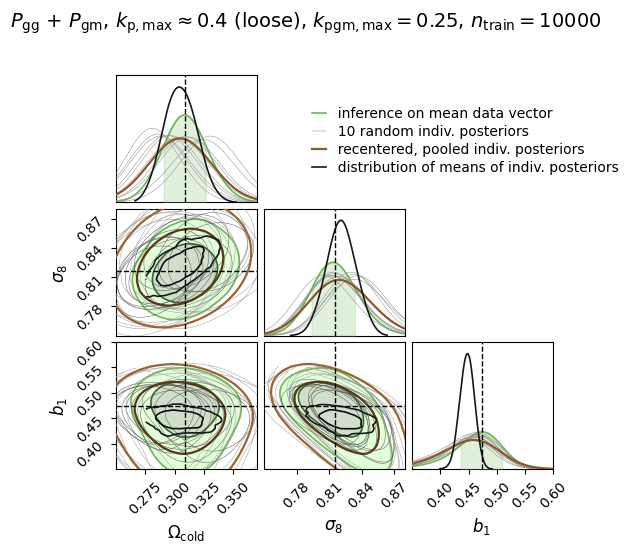

In [4]:
plot_a1_variant(
    tag_masks_row=TAG_MASK_KP04,
    n_train=n_train_fid,
    color_mean=COLOR_FID,
    title=(
        f"{get_stat_label_short(STATISTICS_ROW)}, "
        r"$k_{\mathrm{p,max}}\approx0.4$ (loose), "
        r"$k_{\mathrm{pgm,max}}=0.25$, "
        rf"$n_\mathrm{{train}}={n_train_fid}$"
    ),
    save_name="figA1_pk_pgm_kp0.4_kpgm0.25",
)


### Legacy A1 — key params, full prior extents

Same 3-parameter A1 as above, but axis limits are the full prior edges instead of the zoomed $A1$ window.


$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kpgm0.25_ntrain10000_k500_zoom.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold', 'sigma8_cold', 'b1']
overlaying 10 random indiv. posteriors, obs_idx=[ 85 767  88 649 436 430 695  9

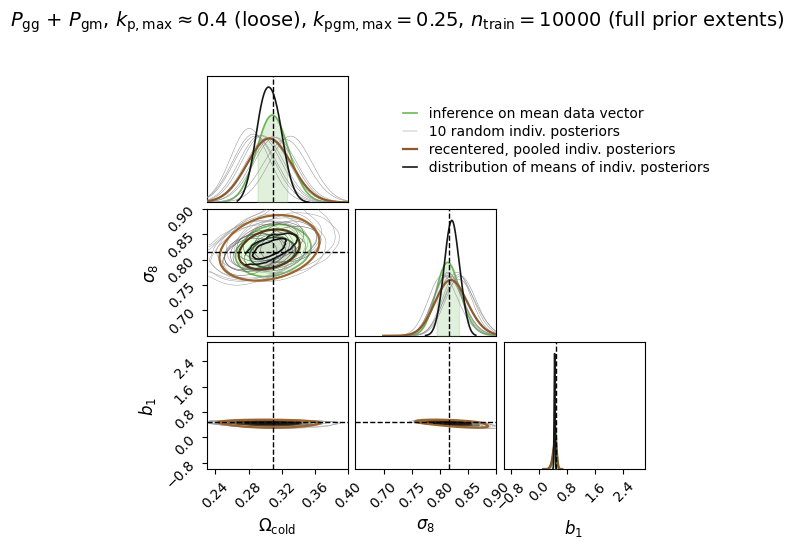

In [5]:
plot_a1_variant(
    tag_masks_row=TAG_MASK_KP04,
    n_train=n_train_fid,
    color_mean=COLOR_FID,
    extents=extents_prior,
    title=(
        f"{get_stat_label_short(STATISTICS_ROW)}, "
        r"$k_{\mathrm{p,max}}\approx0.4$ (loose), "
        r"$k_{\mathrm{pgm,max}}=0.25$, "
        rf"$n_\mathrm{{train}}={n_train_fid}$"
        " (full prior extents)"
    ),
    save_name="figA1_pk_pgm_kp0.4_kpgm0.25_prior_extents",
)


### Legacy A1 — cosmo + bias (no noise)

Triangle over inferred cosmology + bias parameters only ($\Omega_\mathrm{c}$, $\sigma_8$, $b_1$, $b_2$, $b_{s^2}$, $b_\ell$).


$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kpgm0.25_ntrain10000_k500_cosmo_bias.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold', 'sigma8_cold', 'b1', 'b2', 'bs2', 'bl']
overlaying 10 random indiv. posteriors, obs_idx=[ 85 7

Saved: /home/kstoreyf/muchisimocks/figures/2026-09-08_mean_inf_checks/figA1_pk_pgm_kp0.4_kpgm0.25_cosmo_bias.png


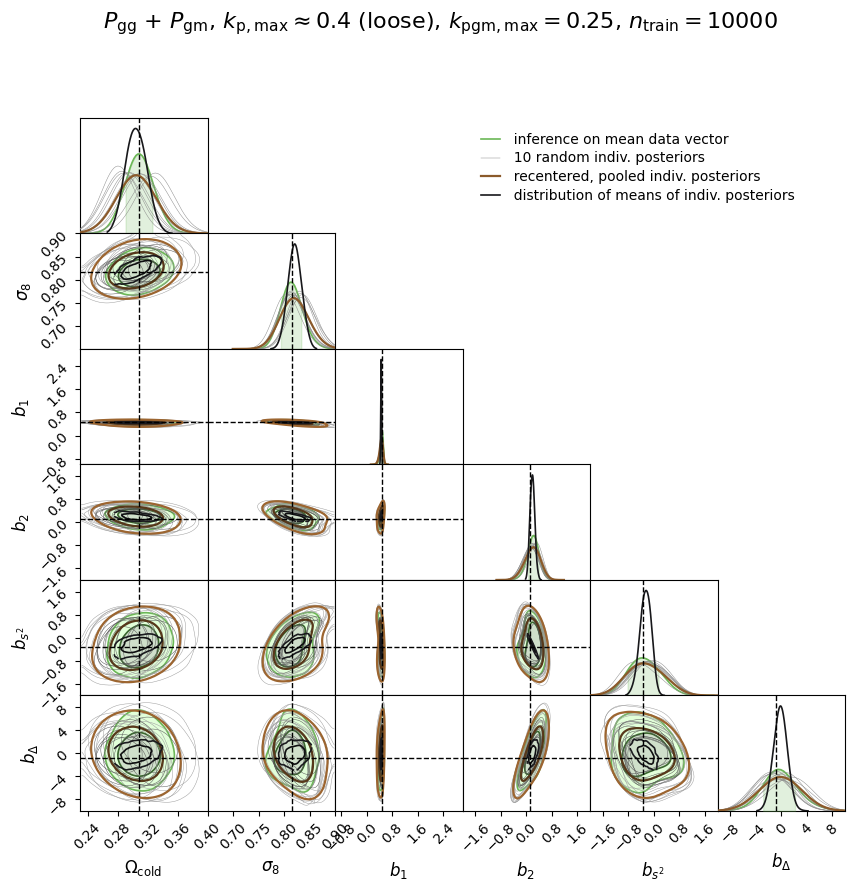

In [6]:
plot_a1_variant(
    tag_masks_row=TAG_MASK_KP04,
    n_train=n_train_fid,
    color_mean=COLOR_FID,
    param_names=PARAM_NAMES_COSMO_BIAS,
    theta_obs_true=THETA_SHOW_COSMO_BIAS,
    extents=extents_prior,
    figsize=FIGSIZE_ALL_PARAMS,
    title=(
        f"{get_stat_label_short(STATISTICS_ROW)}, "
        r"$k_{\mathrm{p,max}}\approx0.4$ (loose), "
        r"$k_{\mathrm{pgm,max}}=0.25$, "
        rf"$n_\mathrm{{train}}={n_train_fid}$"
    ),
    save_name="figA1_pk_pgm_kp0.4_kpgm0.25_cosmo_bias",
)


### Legacy A1 — cosmo + noise (no bias)

Triangle over inferred cosmology + $A_\mathrm{noise}$ parameters (bias marginalized / not shown).


$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kpgm0.25_ntrain10000_k500_cosmo_noise.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold', 'sigma8_cold', 'An_homog', 'An_b1', 'An_b2', 'An_bs2', 'An_bl']
overlaying 10 random indiv. p

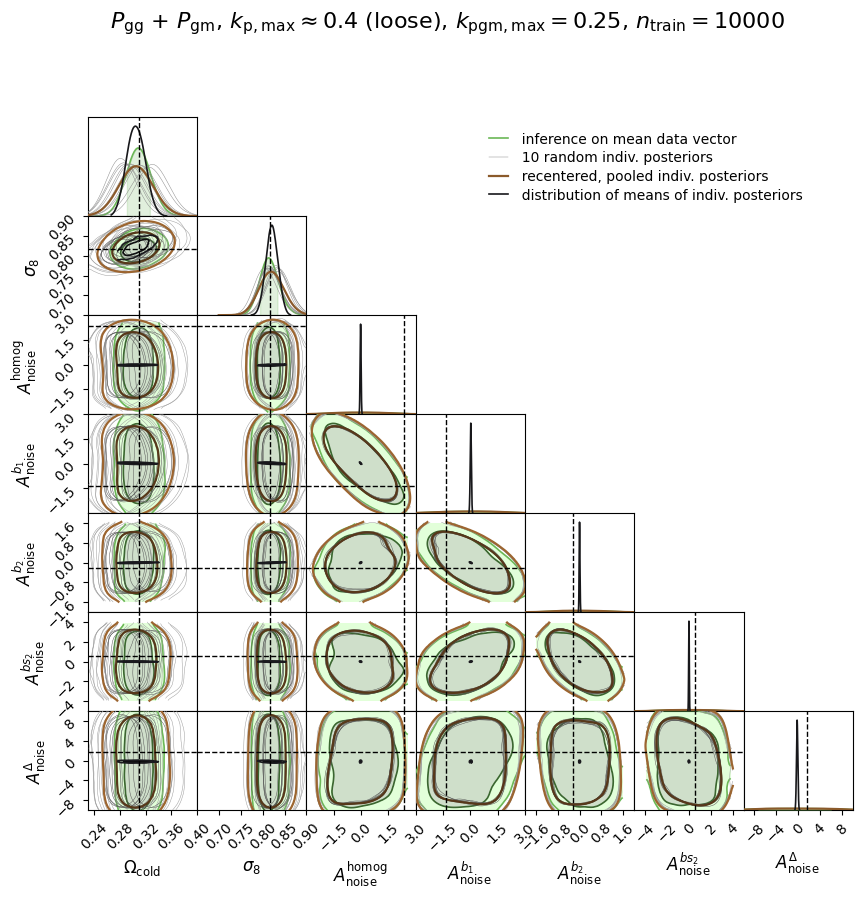

In [7]:
plot_a1_variant(
    tag_masks_row=TAG_MASK_KP04,
    n_train=n_train_fid,
    color_mean=COLOR_FID,
    param_names=PARAM_NAMES_COSMO_NOISE,
    theta_obs_true=THETA_SHOW_COSMO_NOISE,
    extents=extents_prior,
    figsize=FIGSIZE_ALL_PARAMS,
    title=(
        f"{get_stat_label_short(STATISTICS_ROW)}, "
        r"$k_{\mathrm{p,max}}\approx0.4$ (loose), "
        r"$k_{\mathrm{pgm,max}}=0.25$, "
        rf"$n_\mathrm{{train}}={n_train_fid}$"
    ),
    save_name="figA1_pk_pgm_kp0.4_kpgm0.25_cosmo_noise",
)


## New fiducial A1 ($P_\mathrm{gg}+P_\mathrm{gm}$, $k_{\mathrm{p,max}}=0.35$, $k_{\mathrm{pgm,max}}=0.25$, $n_\mathrm{train}=10000$)

Mean-only until indiv samples for `_kp0.35_kpgm0.25` finish.


$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy


Wrote cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kp0.35_kpgm0.25_ntrain10000_k500_zoom.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold', 'sigma8_cold', 'b1']
overlaying 10 random indiv. posteriors, obs_idx=[ 85 767  88 649 436 430 695  94 201 855]
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Saved: /home/kstoreyf/muchisimocks/figures/2026-09-08_mean_inf_checks/figA1_pk_pgm_fiducial.png


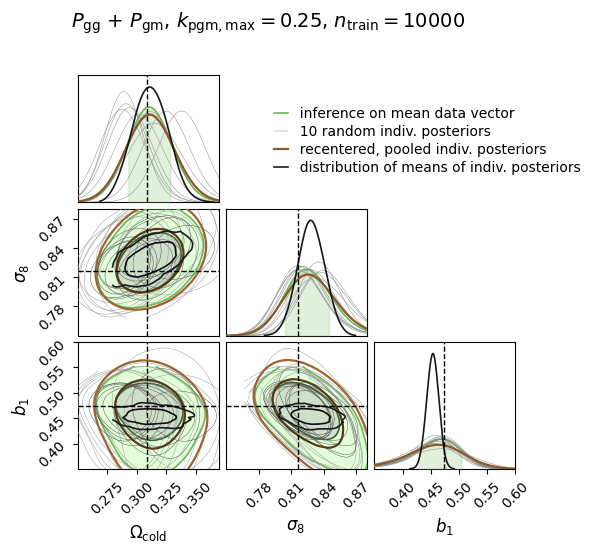

In [8]:
plot_a1_variant(
    tag_masks_row=TAG_MASK_FID,
    n_train=n_train_fid,
    color_mean=COLOR_FID,
    save_name="figA1_pk_pgm_fiducial",
)


## Old vs new fiducial (mean-inf + recentered)

Overlay of legacy (`_kpgm0.25`, $k_{\mathrm{p,max}}\approx0.4$) vs new (`_kp0.35_kpgm0.25`) on the key params. Filled = inference on mean (dark green = old, green = new); brown = recentered pooled (dashed = old, solid = new).


Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kpgm0.25_ntrain10000_k500_zoom.pkl
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kp0.35_kpgm0.25_ntrain10000_k500_zoom.pkl
old mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
new mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_

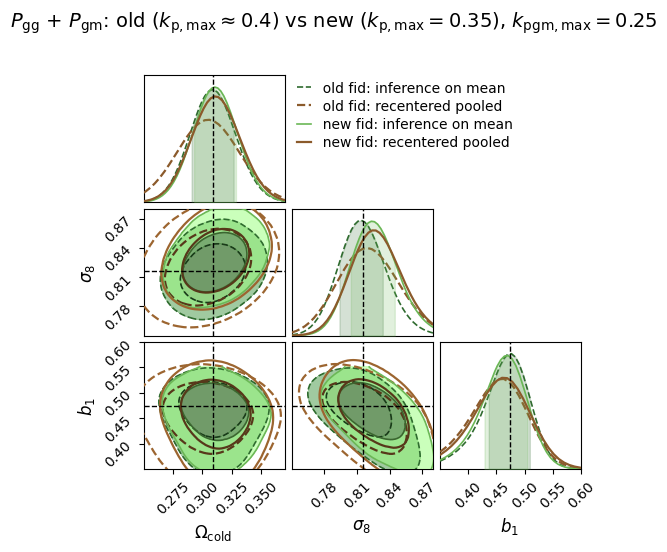

In [11]:
plot_old_vs_new_fiducial(
    save_name="figA1_old_vs_new_fiducial",
)


## New fiducial ensemble ($k=3$)

Top-3 stall-passing models at `_kp0.35_kpgm0.25` (`_best-rand30`, `_nbest1`, `_nbest2`). All three have **CV-mean** samples; CV-indiv exists only for the top model so far. First plot: member mean-inf overlay. Second: top model vs equal-weight $k=3$ mixture of the mean chains.


In [ ]:
plot_new_fid_ensemble_members(
    save_name="figA1_newfid_ensemble_members",
)


In [ ]:
plot_new_fid_top_vs_ensemble(
    save_name="figA1_newfid_top_vs_ensemble",
)


### Fiducial A1 — cosmo + bias (no noise)

Triangle over inferred cosmology + bias parameters only ($\Omega_\mathrm{c}$, $\sigma_8$, $b_1$, $b_2$, $b_{s^2}$, $b_\ell$).


$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Wrote cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kp0.35_kpgm0.25_ntrain10000_k500_cosmo_bias.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold', 'sigma8_cold', 'b1', 'b2', 'bs2', 'bl']
overlaying 10 random

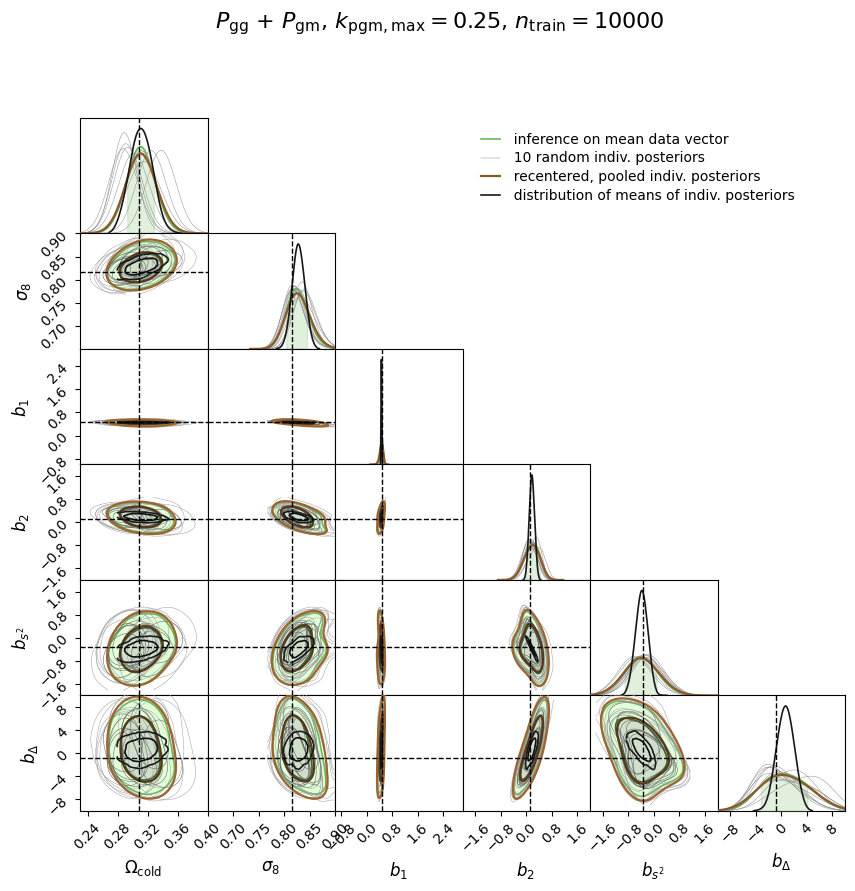

In [9]:
plot_a1_variant(
    tag_masks_row=TAG_MASK_FID,
    n_train=n_train_fid,
    color_mean=COLOR_FID,
    param_names=PARAM_NAMES_COSMO_BIAS,
    theta_obs_true=THETA_SHOW_COSMO_BIAS,
    extents=extents_prior,
    figsize=FIGSIZE_ALL_PARAMS,
    save_name="figA1_pk_pgm_fiducial_cosmo_bias",
)


### Fiducial A1 — cosmo + noise (no bias)

Triangle over inferred cosmology + $A_\mathrm{noise}$ parameters (bias marginalized / not shown).


$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Wrote cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kp0.35_kpgm0.25_ntrain10000_k500_cosmo_noise.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold', 'sigma8_cold', 'An_homog', 'An_b1', 'An_b2', 'An_bs2', 'An_

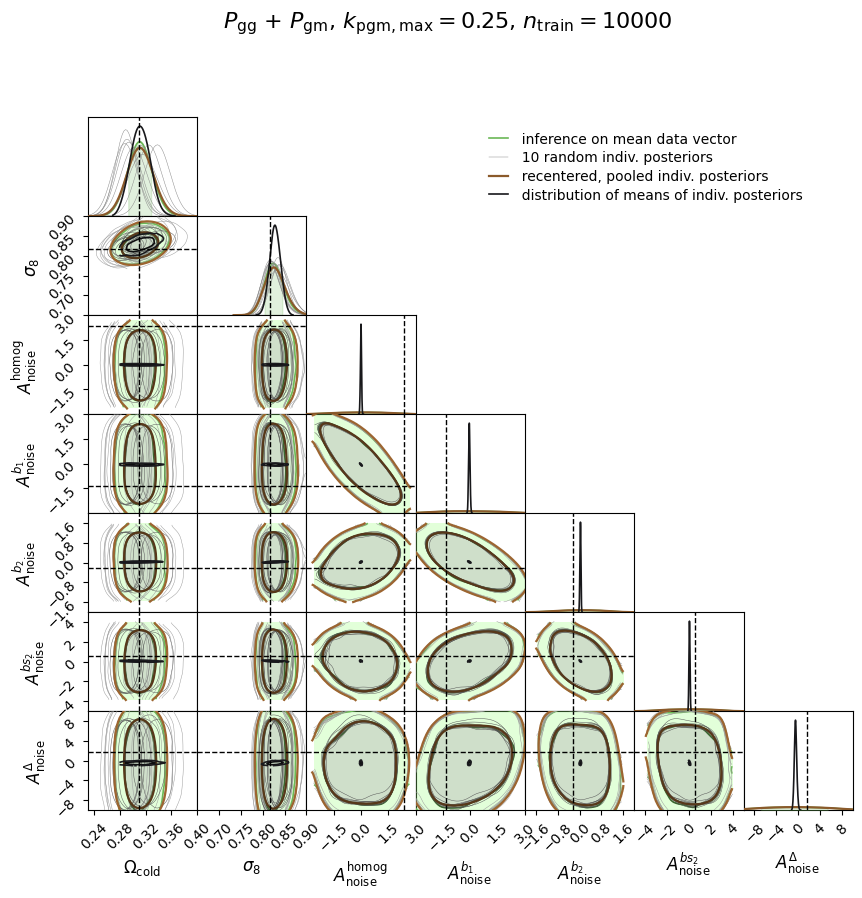

In [10]:
plot_a1_variant(
    tag_masks_row=TAG_MASK_FID,
    n_train=n_train_fid,
    color_mean=COLOR_FID,
    param_names=PARAM_NAMES_COSMO_NOISE,
    theta_obs_true=THETA_SHOW_COSMO_NOISE,
    extents=extents_prior,
    figsize=FIGSIZE_ALL_PARAMS,
    save_name="figA1_pk_pgm_fiducial_cosmo_noise",
)


## Mean-inference vs $k_{\mathrm{pgm,max}}$ (Pk fixed at $0.35$)

Overlay CV-mean posteriors for $P_\mathrm{gg}+P_\mathrm{gm}$ across the PGM $k_\mathrm{max}$ grid with $k_{\mathrm{p,max}}=0.35$. Color scales with $k_{\mathrm{pgm,max}}$.


/tmp/ipykernel_352739/911953636.py:135: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


Missing 1 mean-inf sample file(s):
  /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.35_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.35_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Loaded 9 / 10 mean-inf runs
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.1_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.15_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.15_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n100

Saved: /home/kstoreyf/muchisimocks/figures/2026-09-08_mean_inf_checks/mean_inf_pk_pgm_vs_kpgmmax.png


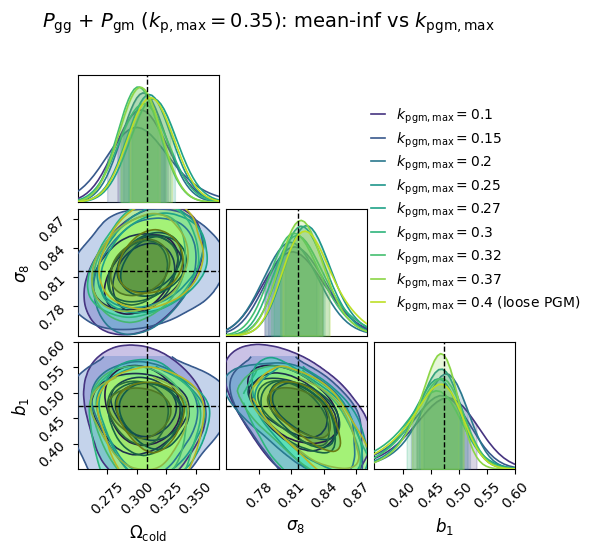

In [11]:
plot_mean_overlay(
    TAGS_KMAX_KPGM,
    [n_train_fid] * len(TAGS_KMAX_KPGM),
    title=rf"{get_stat_label_short(STATISTICS_ROW)} ($k_{{\mathrm{{p,max}}}}=0.35$): mean-inf vs $k_{{\mathrm{{pgm,max}}}}$",
    save_name="mean_inf_pk_pgm_vs_kpgmmax",
)


### Per-$k_{\mathrm{pgm,max}}$ A1 (or mean-only fallback)

Full A1 when CV-sample (indiv.) files exist; otherwise the mean contour alone.


/tmp/ipykernel_352739/911953636.py:135: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


$k_{\mathrm{pgm,max}}=0.1$
$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.1_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.1_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy


Wrote cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kp0.35_kpgm0.1_ntrain10000_k500_zoom.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold', 'sigma8_cold', 'b1']
overlaying 10 random indiv. posteriors, obs_idx=[ 85 767  88 649 436 430 695  94 201 855]
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.1_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Saved: /home/kstoreyf/muchisimocks/figures/2026-09-08_mean_inf_checks/figA1_pk_pgm_kp0.35_kpgm0.1.png


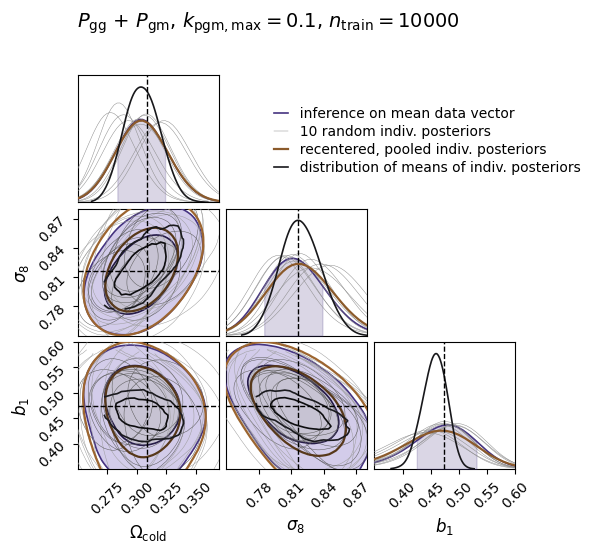

$k_{\mathrm{pgm,max}}=0.15$
$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.15_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.15_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.15_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.15_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Wrote cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kp0.35_kpgm0.15_ntrain10000_k500_zoom.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold', 'sigma8_cold', 'b1']
overlaying 10 ran

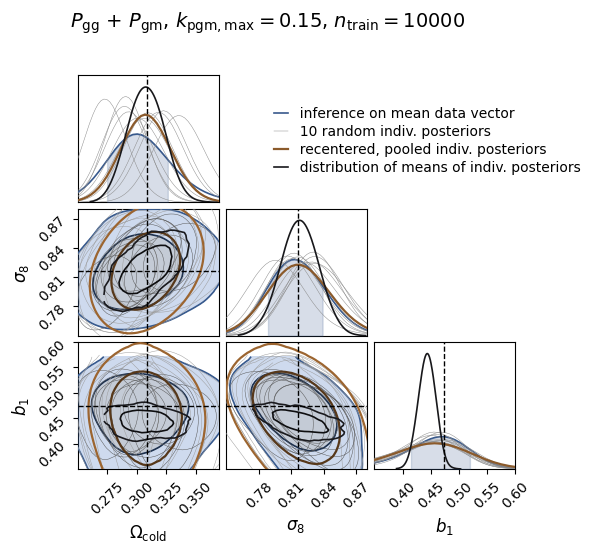

$k_{\mathrm{pgm,max}}=0.2$
$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.2_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.2_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Wrote cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kp0.35_kpgm0.2_ntrain10000_k500_zoom.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold', 'sigma8_cold', 'b1']
overlaying 10 random in

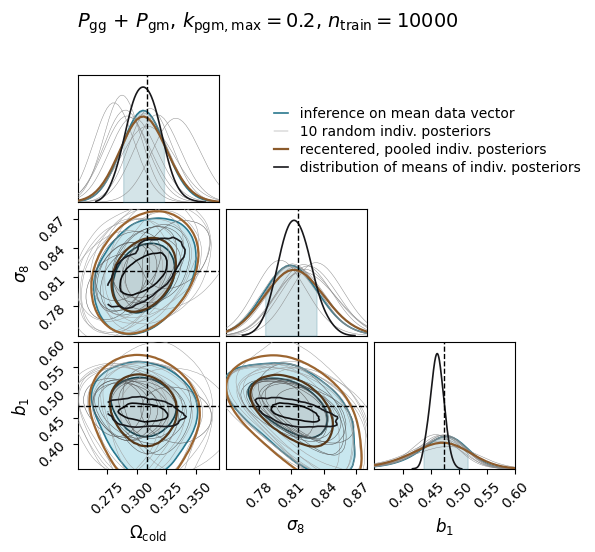

$k_{\mathrm{pgm,max}}=0.25$
$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kp0.35_kpgm0.25_ntrain10000_k500_zoom.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold', 'sigma8_cold', 'b1']
overlaying 10 ra

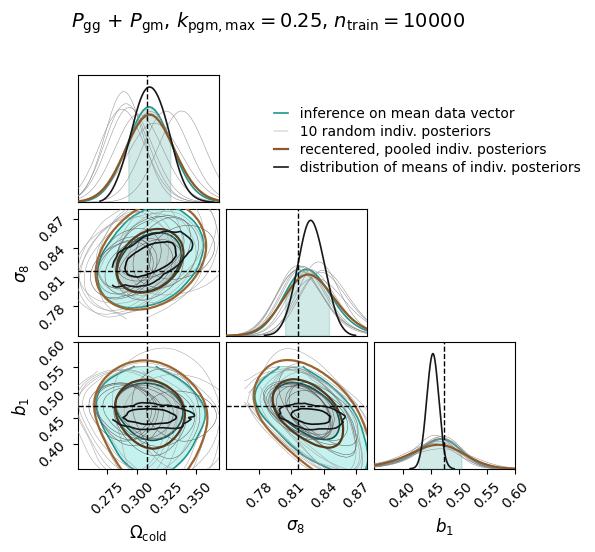

$k_{\mathrm{pgm,max}}=0.27$
$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.27_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.27_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Wrote cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kp0.35_kpgm0.27_ntrain10000_k500_zoom.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold', 'sigma8_cold', 'b1']
overlaying 10 ran

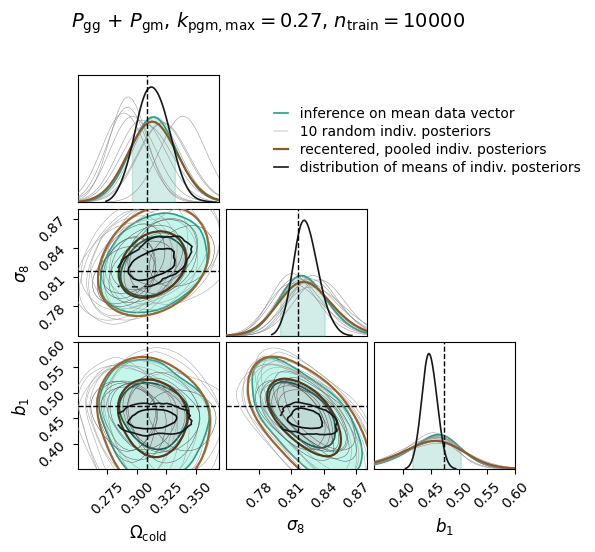

$k_{\mathrm{pgm,max}}=0.3$
$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.3_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.3_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.3_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.3_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Wrote cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kp0.35_kpgm0.3_ntrain10000_k500_zoom.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold', 'sigma8_cold', 'b1']
overlaying 10 random in

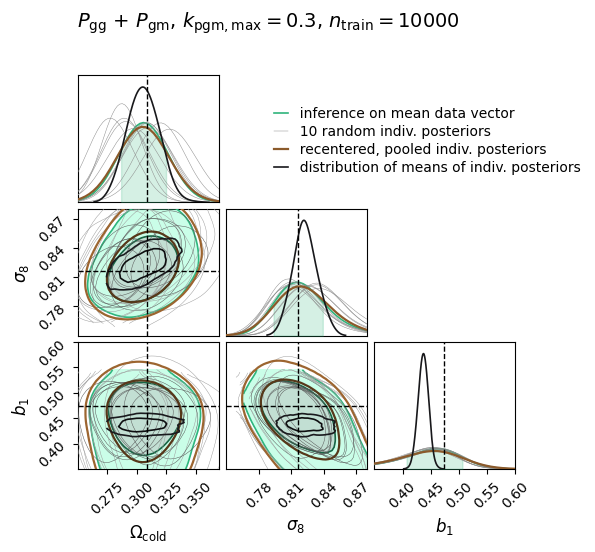

$k_{\mathrm{pgm,max}}=0.32$
$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.32_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.32_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.32_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.32_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Wrote cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kp0.35_kpgm0.32_ntrain10000_k500_zoom.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold', 'sigma8_cold', 'b1']
overlaying 10 ran

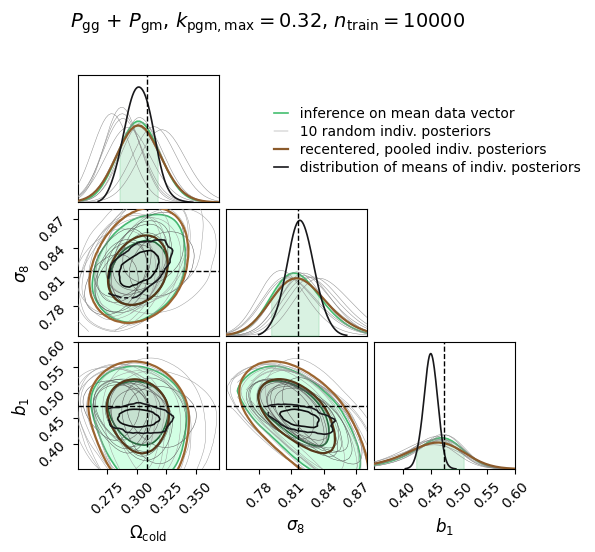

$k_{\mathrm{pgm,max}}=0.35$
MISSING mean samples: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.35_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.35_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
$k_{\mathrm{pgm,max}}=0.37$
$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.37_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.37_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.37_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.37_shame_p0_n1000_biasshame_nois

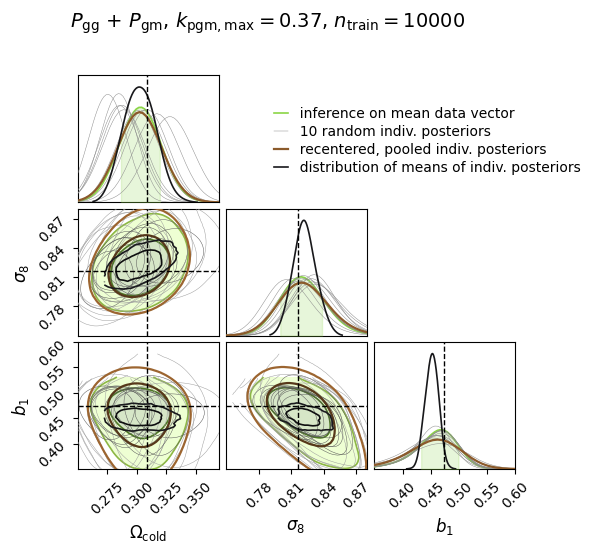

$k_{\mathrm{pgm,max}}=0.4$ (loose PGM)
$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Wrote cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kp0.35_ntrain10000_k500_zoom.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold', 'sigma8_cold', 'b1']
overlaying 10 random indiv. posteriors, obs_idx=[ 8

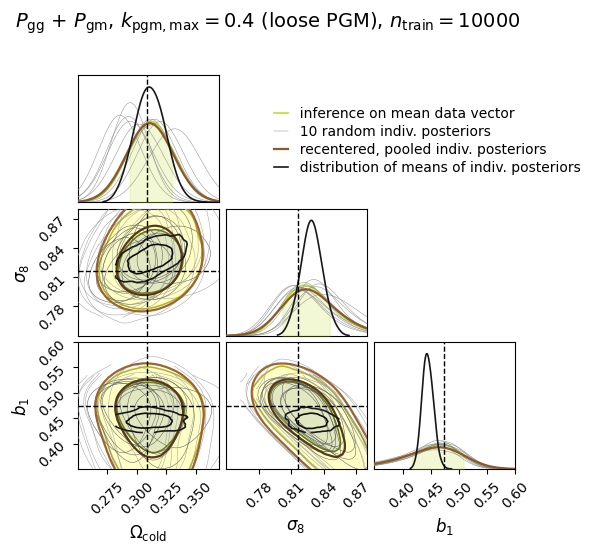

In [12]:
kmax_colors = sequential_colors([kmax_label_from_mask(m) for m in TAGS_KMAX_KPGM])
for tag_mask in TAGS_KMAX_KPGM:
    km = kmax_label_from_mask(tag_mask)
    mask_key = tag_mask.lstrip("_") if tag_mask else "loose"
    print("=" * 60)
    print(kmax_legend_label(tag_mask))
    plot_a1_variant(
        tag_masks_row=tag_mask,
        n_train=n_train_fid,
        color_mean=kmax_colors[km],
        save_name=f"figA1_pk_pgm_{mask_key}",
    )


## Mean-inference vs $n_\mathrm{train}$

Fiducial mask `_kp0.35_kpgm0.25`. Overlay whatever CV-mean posteriors exist; missing $n_\mathrm{train}$ values are listed.

**Note:** only $n_\mathrm{train}=10000$ is trained for this fiducial so far.


/tmp/ipykernel_352739/911953636.py:135: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


Missing 6 mean-inf sample file(s):
  /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain500_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
  /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain1000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
  /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain2000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
  /scratch/kstoreyf/muchisimocks/res

Saved: /home/kstoreyf/muchisimocks/figures/2026-09-08_mean_inf_checks/mean_inf_pk_pgm_vs_ntrain.png


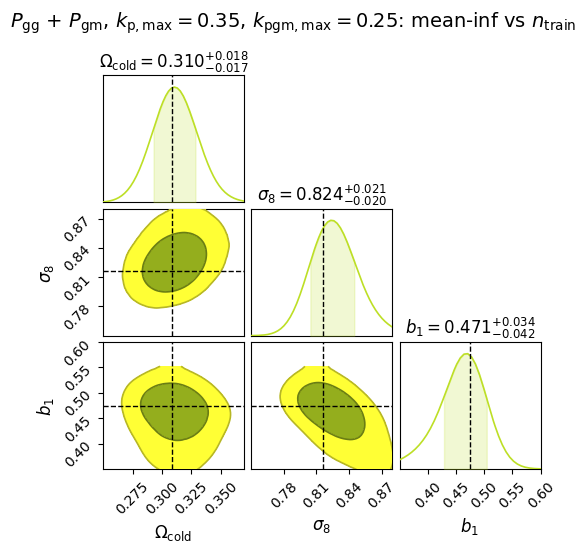

In [13]:
plot_mean_overlay(
    [TAG_MASK_FID] * len(N_TRAIN_ARR),
    N_TRAIN_ARR,
    title=rf"{get_stat_label_short(STATISTICS_ROW)}, $k_{{\mathrm{{p,max}}}}=0.35$, $k_{{\mathrm{{pgm,max}}}}=0.25$: mean-inf vs $n_\mathrm{{train}}$",
    save_name="mean_inf_pk_pgm_vs_ntrain",
)


### Per-$n_\mathrm{train}$ A1 (or mean-only fallback)


/tmp/ipykernel_352739/911953636.py:135: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


n_train = 500
MISSING mean samples: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain500_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
n_train = 1000
MISSING mean samples: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain1000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
n_train = 2000
MISSING mean samples: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain2000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_u

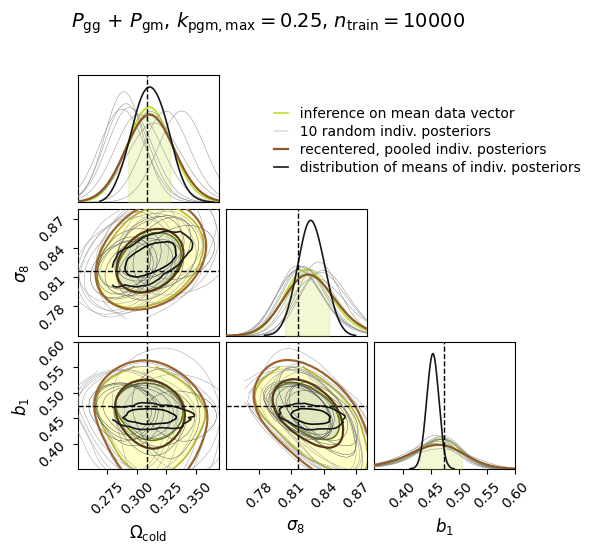

In [14]:
ntrain_colors = sequential_colors(N_TRAIN_ARR)
for n_train in N_TRAIN_ARR:
    print("=" * 60)
    print(rf"n_train = {n_train}")
    plot_a1_variant(
        tag_masks_row=TAG_MASK_FID,
        n_train=n_train,
        color_mean=ntrain_colors[n_train],
        save_name=f"figA1_pk_pgm_kp0.35_kpgm0.25_ntrain{n_train}",
    )


## New fiducial — all stats combos

Same A1 comparisons as above (zoomed key params; cosmo+bias; cosmo+noise) at the new-fiducial $k$-cuts for each statistics combination:

| stats | mask |
|---|---|
| $P_\mathrm{gg}$ | `_kp0.35` |
| $P_\mathrm{gg}+P_\mathrm{gm}$ | `_kp0.35_kpgm0.25` |
| $P_\mathrm{gg}+B_\mathrm{ggg}$ | `_kp0.35_kb0.25` |
| $P_\mathrm{gg}+B_\mathrm{ggg}+P_\mathrm{gm}$ | `_kp0.35_kb0.25_kpgm0.25` |

Full A1 when CV-indiv (shame) samples exist; otherwise mean-only fallback. Colors match the paper fiducial palette.


In [5]:
# Paper fiducial palette / new-fiducial masks (kp=0.35, kb=kpgm=0.25)
STATISTICS_ARR_NEWFID = [
    (["pk"], "_kp0.35", "#79D0EC"),
    (["pk", "pgm"], "_kp0.35_kpgm0.25", "#6BB756"),
    (["pk", "bispec"], "_kp0.35_kb0.25", "#9D86E0"),
    (["pk", "bispec", "pgm"], "_kp0.35_kb0.25_kpgm0.25", "#B32168"),
]
# Full combo (pk+bispec+pgm) — used by ensemble-member comparison section
STATS_FULL_NEWFID, MASK_FULL_NEWFID, COLOR_FULL_NEWFID = STATISTICS_ARR_NEWFID[-1]
# Member shades of the full-combo magenta (best, nbest1, nbest2)
COLORS_FULL_MEMBERS = ["#B32168", "#E06A9A", "#6E1440"]


def _stats_save_key(statistics_row):
    return "_".join(statistics_row)


def _newfid_title(statistics_row, tag_mask, suffix=""):
    base = (
        f"{get_stat_label_short(statistics_row)}, "
        rf"$k_{{\mathrm{{p,max}}}}=0.35$"
    )
    if "_kb" in tag_mask:
        kb = tag_mask.split("_kb", 1)[1].split("_", 1)[0]
        base += rf", $k_{{\mathrm{{b,max}}}}={kb}$"
    if "_kpgm" in tag_mask:
        kpgm = tag_mask.split("_kpgm", 1)[1].split("_", 1)[0]
        base += rf", $k_{{\mathrm{{pgm,max}}}}={kpgm}$"
    if suffix:
        base += f" — {suffix}"
    return base


$P_\mathrm{gg}$: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.35_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_kp0.35_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
$P_\mathrm{gg}$ + $P_\mathrm{gm}$: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
$P_\mathrm{gg}$ + $B_\mathrm{ggg}$: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kp0.35_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
$P_\mathr

Saved: /home/kstoreyf/muchisimocks/figures/2026-09-08_mean_inf_checks/figA1_newfid_all_stats_mean_overlay.png


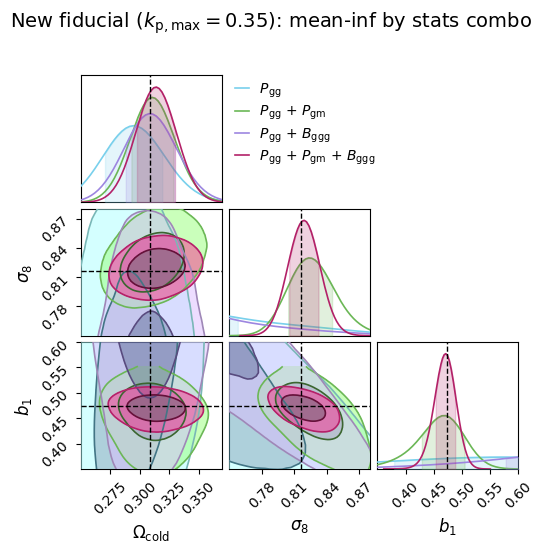

In [6]:
# Mean-inf overlay across stats combos (key params)
_STATISTICS_ROW_SAVE = list(STATISTICS_ROW)

tags_inf, labels, colors, tags_test = [], [], [], []
for stats, mask, color in STATISTICS_ARR_NEWFID:
    STATISTICS_ROW = list(stats)
    tag_inf = build_tag_inf(mask, n_train_fid)
    tag_test = build_tag_test(mask, mean=True)
    fn = sample_fn(tag_inf, tag_test)
    if not fn.exists():
        print(f"MISSING {get_stat_label_short(stats)}: {fn}")
        continue
    print(f"{get_stat_label_short(stats)}: {fn}")
    tags_inf.append(tag_inf)
    tags_test.append(tag_test)
    labels.append(get_stat_label_short(stats))
    colors.append(color)

STATISTICS_ROW = list(_STATISTICS_ROW_SAVE)

if tags_inf:
    fig = plotter.plot_contours_inf(
        param_names=PARAM_NAMES_ZOOM,
        idx_obs=idx_obs,
        theta_obs_true=THETA_SHOW,
        inf_methods=["sbi"] * len(tags_inf),
        tags_inf=tags_inf,
        tags_test=tags_test,
        colors=colors,
        labels=labels,
        shades=[True] * len(tags_inf),
        linewidths=[LW_MEAN] * len(tags_inf),
        fontsize_legend=FONTSIZE_LEGEND,
        legend_location=(0, 1),
        legend_loc="upper left",
        loc_legend=None,
        title=r"New fiducial ($k_{\mathrm{p,max}}=0.35$): mean-inf by stats combo",
        extents=EXTENTS_A,
        figsize=FIGSIZE_CORNER,
        unreparameterize=True,
        samples_list=[None] * len(tags_inf),
        show=False,
    )
    if fig is not None:
        save_figure(fig, "figA1_newfid_all_stats_mean_overlay")
    plt.show()
else:
    print("No stats-combo mean samples found.")


$P_\mathrm{gg}$ _kp0.35 (extents=wide)
$P_\mathrm{gg}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.35_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_kp0.35_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.35_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_kp0.35_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_kp0.35_ntrain10000_k500_zoom.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold', 'sigma8_cold', 'b1']


overlaying 10 random indiv. posteriors, obs_idx=[ 85 767  88 649 436 430 695  94 201 855]
skipping distribution of means of indiv. posteriors
marking mean of means (recentering center θ̄): omega_cold=0.29737, sigma8_cold=0.73103, b1=0.53225
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.35_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_kp0.35_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Saved: /home/kstoreyf/muchisimocks/figures/2026-09-08_mean_inf_checks/figA1_pk_newfid_zoom.png


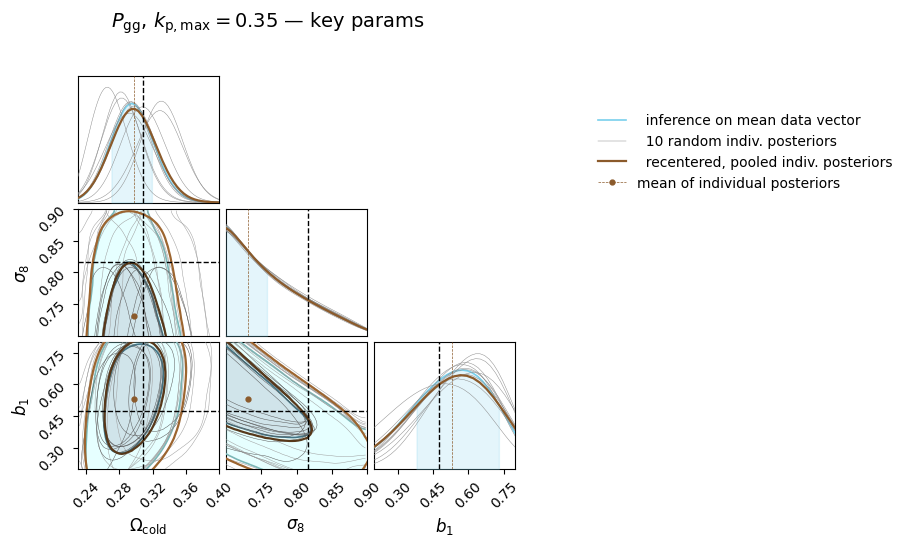

$P_\mathrm{gg}$ + $P_\mathrm{gm}$ _kp0.35_kpgm0.25 (extents=narrow)
$P_\mathrm{gg}$ + $P_\mathrm{gm}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_pgm_kp0.35_kpgm0.25_ntrain10000_k500_zoom.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_cold

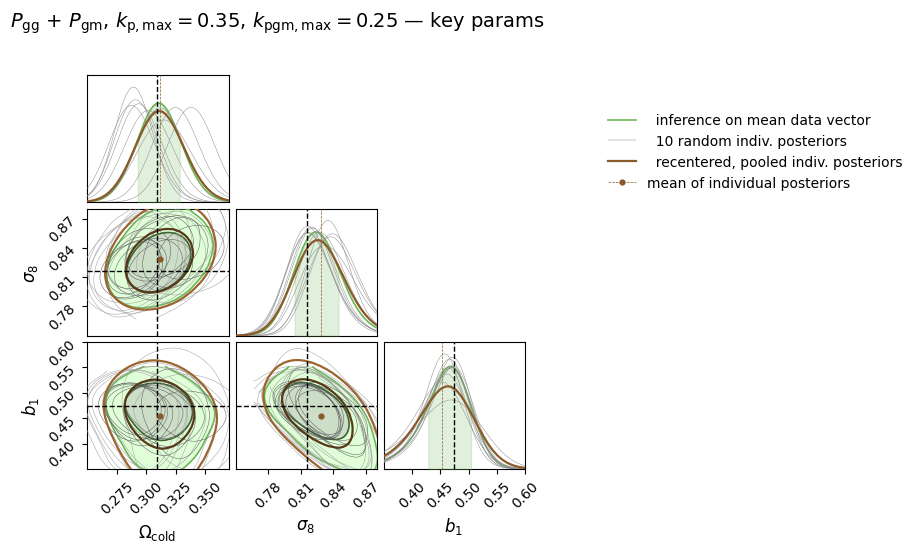

$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ _kp0.35_kb0.25 (extents=wide)
$P_\mathrm{gg}$ + $B_\mathrm{ggg}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kp0.35_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kp0.35_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_bispec_kp0.35_kb0.25_ntrain10000_k500_zoom.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500); params=['omega_c

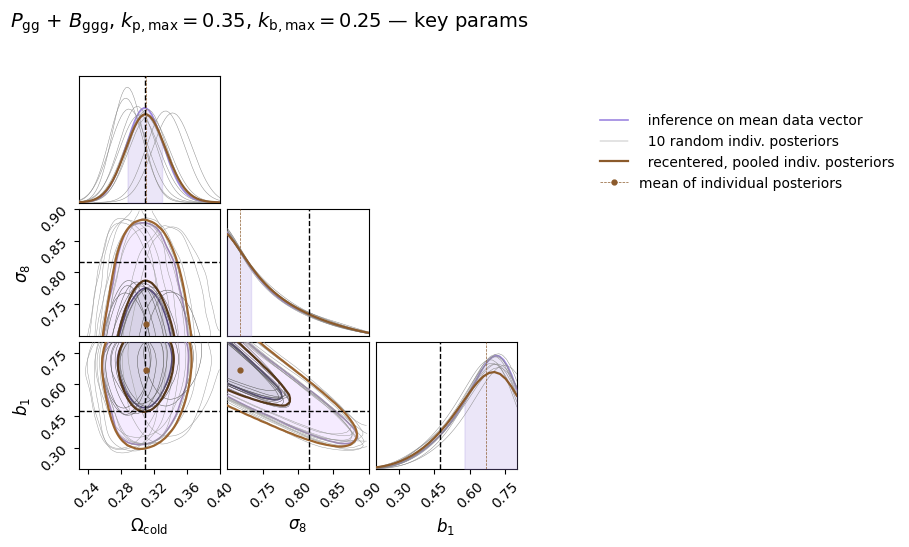

$P_\mathrm{gg}$ + $P_\mathrm{gm}$ + $B_\mathrm{ggg}$ _kp0.35_kb0.25_kpgm0.25 (extents=narrow)
$P_\mathrm{gg}$ + $P_\mathrm{gm}$ + $B_\mathrm{ggg}$: indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_ntrain10000_k500_zoom.pkl
contouring

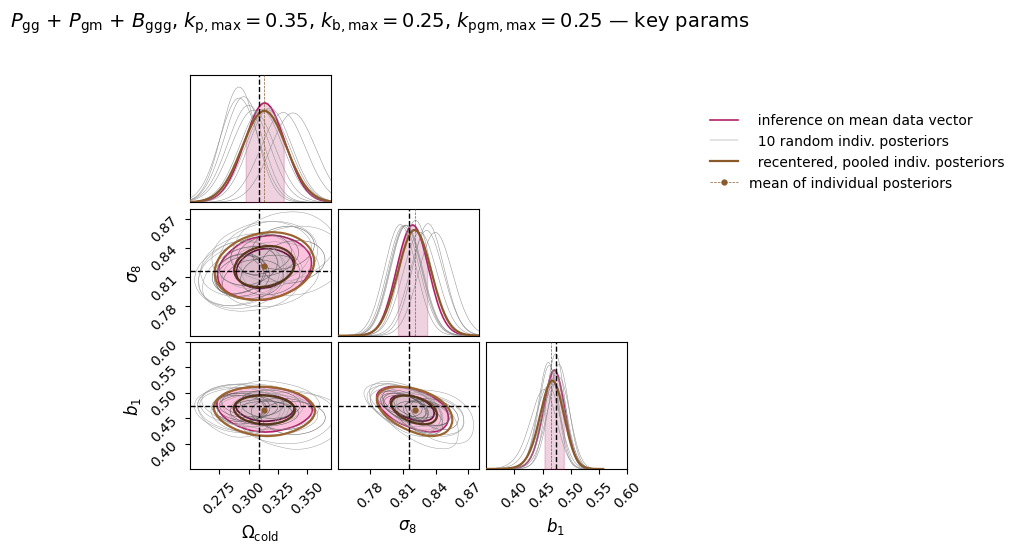

Restored STATISTICS_ROW = ['pk', 'pgm']


In [7]:
# Per-combo A1: zoom (no black indiv-means contour; brown mean-of-means mark)
# Wider b1/σ8 extents for pk and pk+bispec (no Pgm; broader posteriors)
_STATISTICS_ROW_SAVE = list(STATISTICS_ROW)

for stats, mask, color in STATISTICS_ARR_NEWFID:
    STATISTICS_ROW = list(stats)
    skey = _stats_save_key(stats)
    extents = EXTENTS_A if "pgm" in stats else EXTENTS_A_WIDE
    print("=" * 70)
    print(get_stat_label_short(stats), mask, f"(extents={'narrow' if 'pgm' in stats else 'wide'})")
    plot_a1_variant(
        tag_masks_row=mask,
        n_train=n_train_fid,
        color_mean=color,
        param_names=PARAM_NAMES_ZOOM,
        theta_obs_true=THETA_SHOW,
        extents=extents,
        figsize=FIGSIZE_CORNER,
        title=_newfid_title(stats, mask, "key params"),
        save_name=f"figA1_{skey}_newfid_zoom",
        plot_indiv_means=False,
        mark_mean_of_means=True,
    )

STATISTICS_ROW = list(_STATISTICS_ROW_SAVE)
print("Restored STATISTICS_ROW =", STATISTICS_ROW)


## New fiducial — all stats combos, ensemble $k=3$

Same per-combo A1 zoom as above (no black indiv-means contour; brown mean-of-means mark; wider extents for pk / pk+bispec), but:

- **colored contour** = equal-weight mix of top-$k=3$ CV-mean chains (`_best-rand30`, `_nbest1`, `_nbest2`)
- **grey / recentered / mean-of-means** from stacking the three members' CV-indiv samples per realization


$P_\mathrm{gg}$ _kp0.35 (ensemble k=3, extents=wide)


2026-09-11 20:03:19.851845: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-11 20:03:19.892461: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-11 20:03:19.993947: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-11 20:03:19.993993: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-11 20:03:20.011078: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

$P_\mathrm{gg}$ ensemble k=3 CV-mean mix shape=(5000, 3)
  nbest0 indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.35_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_kp0.35_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  nbest1 indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.35_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_muchisimocks_pk_kp0.35_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  nbest2 indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.35_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest2/samples_test_muchisimocks_pk_kp0.35_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
Wrote cache: /home/kstoreyf/muchisimocks/fig

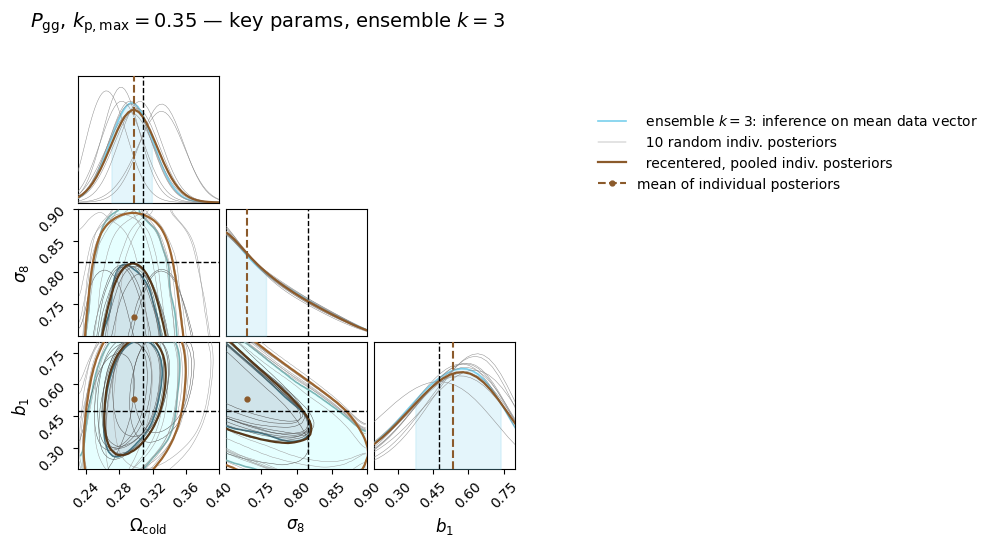

$P_\mathrm{gg}$ + $P_\mathrm{gm}$ _kp0.35_kpgm0.25 (ensemble k=3, extents=narrow)
$P_\mathrm{gg}$ + $P_\mathrm{gm}$ ensemble k=3 CV-mean mix shape=(5000, 3)
  nbest0 indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  nbest1 indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_muchisimocks_pk_pgm_kp0.35_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  nbest2 indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand3

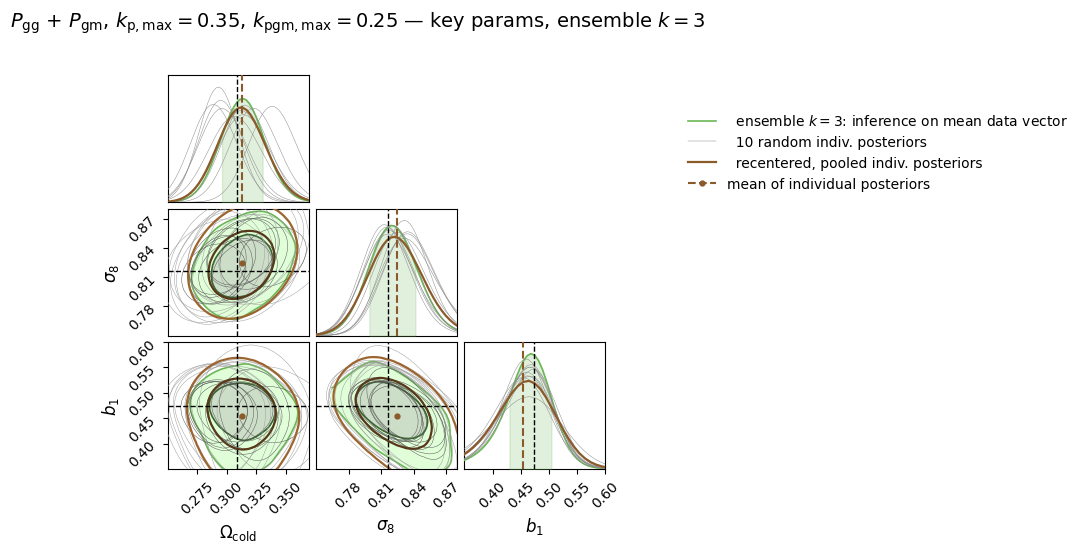

$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ _kp0.35_kb0.25 (ensemble k=3, extents=wide)
$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ ensemble k=3 CV-mean mix shape=(5000, 3)
  nbest0 indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kp0.35_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  nbest1 indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_muchisimocks_pk_bispec_kp0.35_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  nbest2 indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-ra

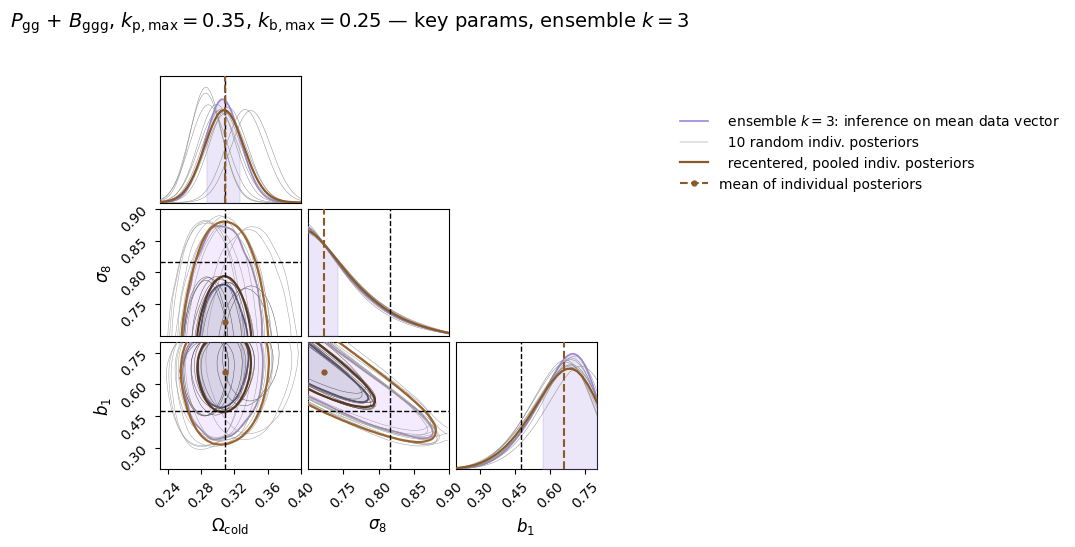

$P_\mathrm{gg}$ + $P_\mathrm{gm}$ + $B_\mathrm{ggg}$ _kp0.35_kb0.25_kpgm0.25 (ensemble k=3, extents=narrow)
$P_\mathrm{gg}$ + $P_\mathrm{gm}$ + $B_\mathrm{ggg}$ ensemble k=3 CV-mean mix shape=(5000, 3)
  nbest0 indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  nbest1 indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  nbest2 indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispe

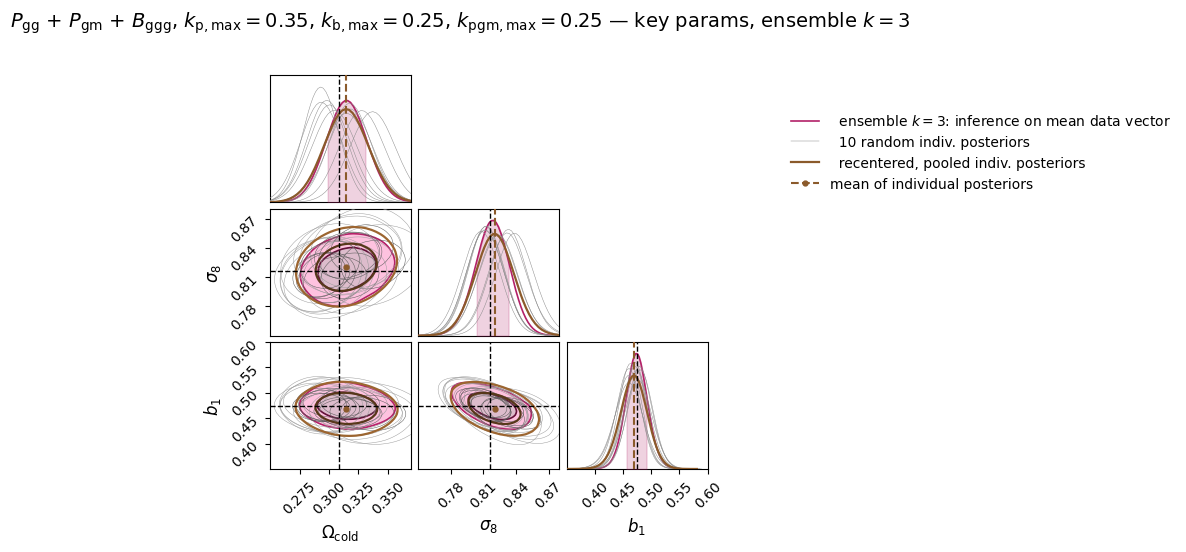

Restored STATISTICS_ROW = ['pk', 'pgm']


In [7]:
# Per-combo A1 ensemble k=3: same style as single-model newfid zoom
_STATISTICS_ROW_SAVE = list(STATISTICS_ROW)

for stats, mask, color in STATISTICS_ARR_NEWFID:
    STATISTICS_ROW = list(stats)
    skey = _stats_save_key(stats)
    extents = EXTENTS_A if "pgm" in stats else EXTENTS_A_WIDE
    print("=" * 70)
    print(
        get_stat_label_short(stats), mask,
        f"(ensemble k={N_ENSEMBLE_K}, extents={'narrow' if 'pgm' in stats else 'wide'})",
    )
    plot_a1_ensemble_variant(
        tag_masks_row=mask,
        n_train=n_train_fid,
        color_mean=color,
        param_names=PARAM_NAMES_ZOOM,
        theta_obs_true=THETA_SHOW,
        extents=extents,
        figsize=FIGSIZE_CORNER,
        title=_newfid_title(
            stats, mask, rf"key params, ensemble $k={N_ENSEMBLE_K}$"
        ),
        save_name=f"figA1_{skey}_newfid_zoom_ensK{N_ENSEMBLE_K}",
        plot_indiv_means=False,
        mark_mean_of_means=True,
        k_members=N_ENSEMBLE_K,
    )

STATISTICS_ROW = list(_STATISTICS_ROW_SAVE)
print("Restored STATISTICS_ROW =", STATISTICS_ROW)


## Full stats combo (`pk`+`bispec`+`pgm`) — ensemble member comparisons

All plots/tables below use **$P_\mathrm{gg}+B_\mathrm{ggg}+P_\mathrm{gm}$** at `_kp0.35_kb0.25_kpgm0.25` (paper color `#B32168`), not the notebook-default `pk`+`pgm`.

1. Mean-inf vs recentered for each of `best` / `nbest1` / `nbest2`
2. Overlay of the 3 recentered posteriors
3. Overlay of the 3 mean-inf posteriors
4. Width table (mean-inf vs recentered; members + ensemble; fractional diffs)


STATISTICS_ROW for this section: ['pk', 'bispec', 'pgm'] _kp0.35_kb0.25_kpgm0.25 #B32168
$P_\mathrm{gg}$ + $P_\mathrm{gm}$ + $B_\mathrm{ggg}$ _kp0.35_kb0.25_kpgm0.25 best #B32168
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_ntrain10000_k500_zoom.pkl
mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
recentered pooled: (500000, 3)
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_shame_p0_n1000_biassh

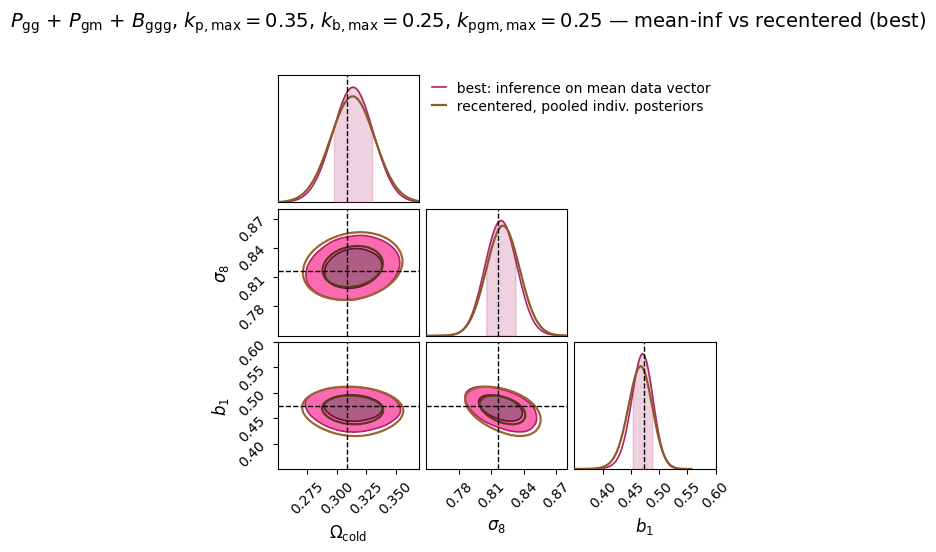

$P_\mathrm{gg}$ + $P_\mathrm{gm}$ + $B_\mathrm{ggg}$ _kp0.35_kb0.25_kpgm0.25 nbest1 #E06A9A
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_ntrain10000_k500_zoom_nbest1.pkl
mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
recentered pooled: (500000, 3)
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Saved:

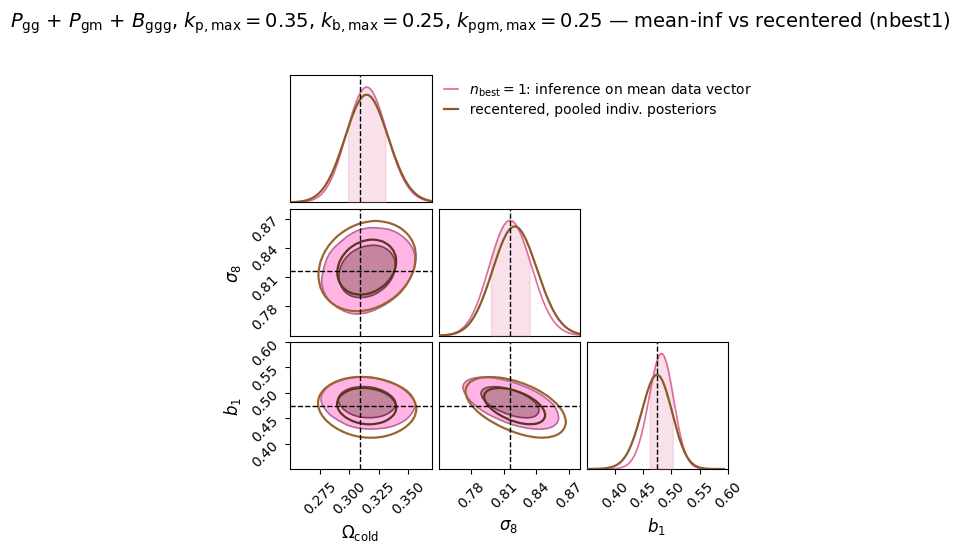

$P_\mathrm{gg}$ + $P_\mathrm{gm}$ + $B_\mathrm{ggg}$ _kp0.35_kb0.25_kpgm0.25 nbest2 #6E1440
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_ntrain10000_k500_zoom_nbest2.pkl
mean = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest2/samples_test_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
recentered pooled: (500000, 3)
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest2/samples_test_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Saved:

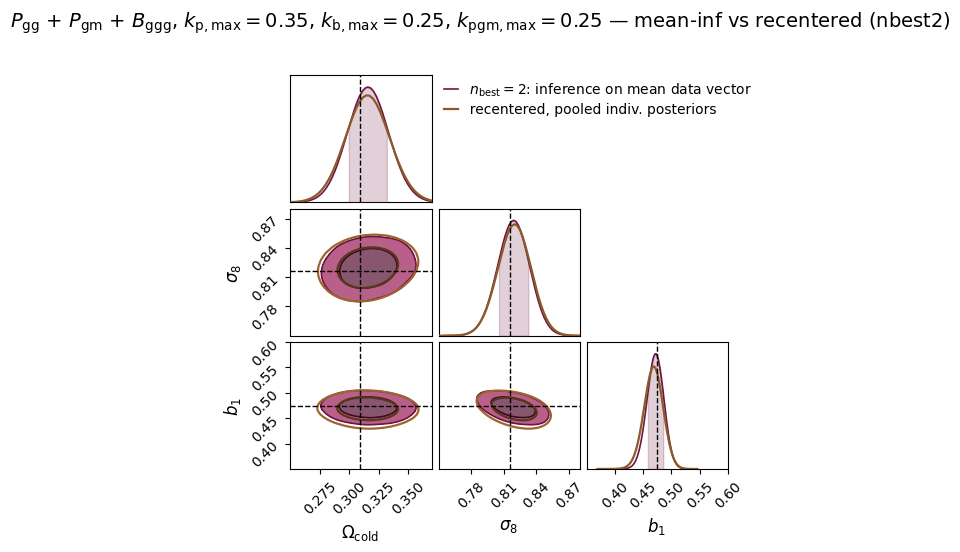

Stored MEMBER_RESULTS for 3 members; STATISTICS_ROW=['pk', 'bispec', 'pgm']


In [20]:
# Full combo pk+bispec+pgm: mean-inf vs recentered for each ensemble member
STATS_FULL, MASK_FULL, COLOR_FULL = STATS_FULL_NEWFID, MASK_FULL_NEWFID, COLOR_FULL_NEWFID
STATISTICS_ROW = list(STATS_FULL)  # lock this section to full combo
skey = _stats_save_key(STATS_FULL)
print("STATISTICS_ROW for this section:", STATISTICS_ROW, MASK_FULL, COLOR_FULL)

MEMBER_RESULTS = []
for nth in range(N_ENSEMBLE_K):
    nbest = nth if nth > 0 else None
    color = COLORS_FULL_MEMBERS[nth % len(COLORS_FULL_MEMBERS)]
    member_tag = "best" if nbest is None else f"nbest{nbest}"
    print("=" * 70)
    print(get_stat_label_short(STATS_FULL), MASK_FULL, member_tag, color)
    res = plot_mean_vs_recentered(
        tag_masks_row=MASK_FULL,
        n_train=n_train_fid,
        color_mean=color,
        nbest=nbest,
        param_names=PARAM_NAMES_ZOOM,
        extents=EXTENTS_A,
        figsize=FIGSIZE_CORNER,
        title=_newfid_title(
            STATS_FULL, MASK_FULL, f"mean-inf vs recentered ({member_tag})"
        ),
        save_name=f"figA1_{skey}_newfid_mean_vs_rc_{member_tag}",
    )
    if res is not None:
        MEMBER_RESULTS.append(res)

print(f"Stored MEMBER_RESULTS for {len(MEMBER_RESULTS)} members; STATISTICS_ROW={STATISTICS_ROW}")


Saved: /home/kstoreyf/muchisimocks/figures/2026-09-08_mean_inf_checks/figA1_pk_bispec_pgm_newfid_recentered_3members.png


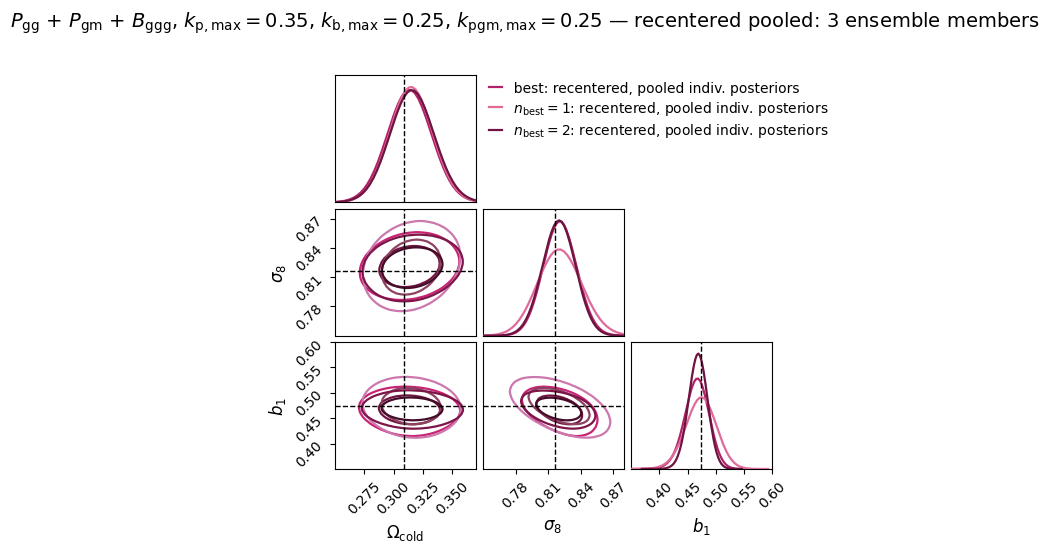

In [21]:
# Overlay the 3 members' recentered pooled posteriors (pk+bispec+pgm)
STATS_FULL, MASK_FULL, COLOR_FULL = STATS_FULL_NEWFID, MASK_FULL_NEWFID, COLOR_FULL_NEWFID
STATISTICS_ROW = list(STATS_FULL)
skey = _stats_save_key(STATS_FULL)

if "MEMBER_RESULTS" not in globals() or len(MEMBER_RESULTS) < N_ENSEMBLE_K:
    raise RuntimeError("Run the per-member mean-vs-recentered cell first (MEMBER_RESULTS).")

names_plot = list(MEMBER_RESULTS[0]["names_plot"])
samples_list, colors, labels = [], [], []
for nth, res in enumerate(MEMBER_RESULTS):
    samples_list.append((res["recentered"], names_plot))
    colors.append(COLORS_FULL_MEMBERS[nth % len(COLORS_FULL_MEMBERS)])
    labels.append(f"{res['label']}: {LABEL_RECENTERED}")

fig = plotter.plot_contours_inf(
    param_names=names_plot,
    idx_obs=idx_obs,
    theta_obs_true=THETA_SHOW,
    inf_methods=["sbi"] * N_ENSEMBLE_K,
    tags_inf=[res["tag_inf"] for res in MEMBER_RESULTS],
    tags_test=[None] * N_ENSEMBLE_K,
    colors=colors,
    labels=labels,
    shades=[False] * N_ENSEMBLE_K,
    linewidths=[LW_RECENTERED] * N_ENSEMBLE_K,
    fontsize_legend=FONTSIZE_LEGEND,
    legend_location=(0, 1),
    legend_loc="upper left",
    loc_legend=None,
    title=_newfid_title(STATS_FULL, MASK_FULL, r"recentered pooled: 3 ensemble members"),
    extents=EXTENTS_A,
    figsize=FIGSIZE_CORNER,
    unreparameterize=True,
    samples_list=samples_list,
    show=False,
)
if fig is not None:
    save_figure(fig, f"figA1_{skey}_newfid_recentered_3members")
plt.show()


Saved: /home/kstoreyf/muchisimocks/figures/2026-09-08_mean_inf_checks/figA1_pk_bispec_pgm_newfid_meaninf_3members.png


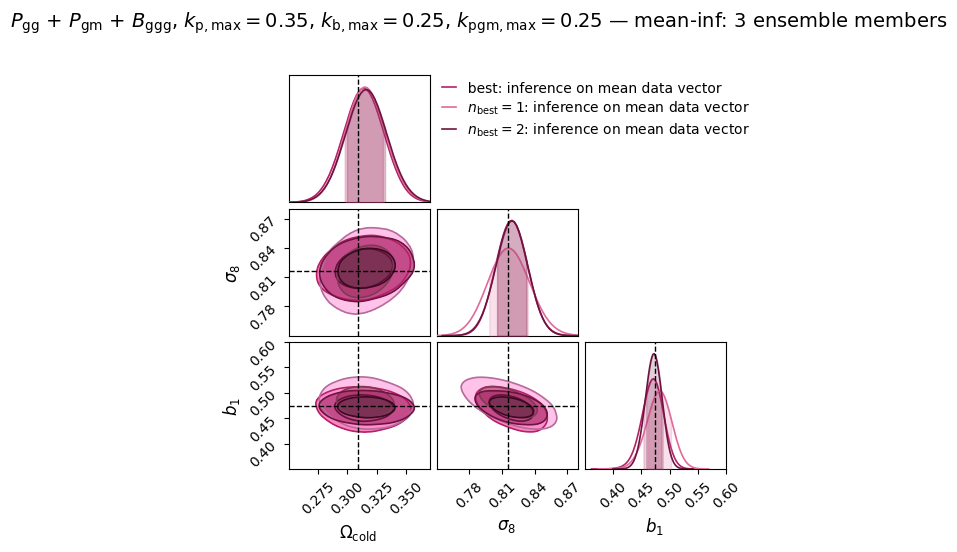

In [22]:
# Overlay the 3 members' CV-mean-inf posteriors (pk+bispec+pgm)
STATS_FULL, MASK_FULL, COLOR_FULL = STATS_FULL_NEWFID, MASK_FULL_NEWFID, COLOR_FULL_NEWFID
STATISTICS_ROW = list(STATS_FULL)
skey = _stats_save_key(STATS_FULL)

if "MEMBER_RESULTS" not in globals() or len(MEMBER_RESULTS) < N_ENSEMBLE_K:
    raise RuntimeError("Run the per-member mean-vs-recentered cell first (MEMBER_RESULTS).")

names_plot = list(MEMBER_RESULTS[0]["names_plot"])
samples_list, colors, labels = [], [], []
for nth, res in enumerate(MEMBER_RESULTS):
    samples_list.append((res["mean_samples"], names_plot))
    colors.append(COLORS_FULL_MEMBERS[nth % len(COLORS_FULL_MEMBERS)])
    labels.append(f"{res['label']}: inference on mean data vector")

fig = plotter.plot_contours_inf(
    param_names=names_plot,
    idx_obs=idx_obs,
    theta_obs_true=THETA_SHOW,
    inf_methods=["sbi"] * N_ENSEMBLE_K,
    tags_inf=[res["tag_inf"] for res in MEMBER_RESULTS],
    tags_test=[None] * N_ENSEMBLE_K,
    colors=colors,
    labels=labels,
    shades=[True] * N_ENSEMBLE_K,
    linewidths=[LW_MEAN] * N_ENSEMBLE_K,
    fontsize_legend=FONTSIZE_LEGEND,
    legend_location=(0, 1),
    legend_loc="upper left",
    loc_legend=None,
    title=_newfid_title(STATS_FULL, MASK_FULL, r"mean-inf: 3 ensemble members"),
    extents=EXTENTS_A,
    figsize=FIGSIZE_CORNER,
    unreparameterize=True,
    samples_list=samples_list,
    show=False,
)
if fig is not None:
    save_figure(fig, f"figA1_{skey}_newfid_meaninf_3members")
plt.show()


In [29]:
# Posterior widths (½ of 16–84% range): mean-inf vs recentered
# for each ensemble member + total ensemble
# frac_width = (w_rc − w_mean) / w_mean
# Δμ/σ_mean = (⟨rc⟩ − ⟨mean-inf⟩) / w_mean  (center offset in units of mean-inf σ)
# Locked to pk+bispec+pgm full combo
STATS_FULL, MASK_FULL, COLOR_FULL = STATS_FULL_NEWFID, MASK_FULL_NEWFID, COLOR_FULL_NEWFID
STATISTICS_ROW = list(STATS_FULL)
print("Widths for", get_stat_label_short(STATS_FULL), MASK_FULL)

rows = []
# per-member (reuse MEMBER_RESULTS if present, else reload)
member_payloads = []
if "MEMBER_RESULTS" in globals() and MEMBER_RESULTS:
    member_payloads = list(MEMBER_RESULTS)
if len(member_payloads) < N_ENSEMBLE_K:
    member_payloads = []
    for nth in range(N_ENSEMBLE_K):
        nbest = nth if nth > 0 else None
        tag_inf = build_tag_inf(MASK_FULL, n_train_fid, nbest=nbest)
        tag_test_mean = build_tag_test(MASK_FULL, mean=True)
        mean_zoom, names_plot = load_mean_samples_zoom(
            tag_inf, tag_test_mean, param_names=PARAM_NAMES_ZOOM,
        )
        bundle = load_recentered_bundle(
            MASK_FULL, n_train_fid, param_names=PARAM_NAMES_ZOOM, nbest=nbest,
        )
        member_payloads.append(dict(
            label=("best" if nbest is None else f"nbest{nbest}"),
            names_plot=names_plot,
            mean_samples=mean_zoom,
            recentered=bundle["pooled_recentered"],
            tag_inf=tag_inf,
        ))


def _width_row(model, names, mean_samples, recentered):
    w_mean = _symmetrized_68_widths(mean_samples)
    w_rc = _symmetrized_68_widths(recentered)
    mu_mean = np.mean(mean_samples, axis=0)
    mu_rc = np.mean(recentered, axis=0)
    out = []
    for i, pn in enumerate(names):
        wm = float(w_mean[i])
        wr = float(w_rc[i])
        out.append(dict(
            model=model,
            param=pn,
            width_mean=wm,
            width_recentered=wr,
            frac_width=(wr - wm) / wm,
            delta_mu_over_sigma=float(mu_rc[i] - mu_mean[i]) / wm,
        ))
    return out


for res in member_payloads:
    rows.extend(_width_row(
        res["label"], list(res["names_plot"]),
        res["mean_samples"], res["recentered"],
    ))

# total ensemble
ens = load_ensemble_mean_and_recentered(
    MASK_FULL, n_train_fid, param_names=PARAM_NAMES_ZOOM, k_members=N_ENSEMBLE_K,
)
rows.extend(_width_row(
    f"ensemble k={N_ENSEMBLE_K}", list(ens["names_plot"]),
    ens["mean_samples"], ens["recentered"],
))
w_mean_e = _symmetrized_68_widths(ens["mean_samples"])
w_rc_e = _symmetrized_68_widths(ens["recentered"])

print(
    f"{get_stat_label_short(STATS_FULL)} {MASK_FULL}: "
    "symmetrized 68% widths (½ of 16–84); "
    "Δμ/σ = (⟨rc⟩−⟨mean⟩)/w_mean\n"
)
hdr = (
    f"{'model':18s} {'param':14s} {'w_mean':>10s} {'w_rc':>10s} "
    f"{'(rc-m)/m':>10s} {'Δμ/σ_mean':>10s}"
)
print(hdr)
print("-" * len(hdr))
for r in rows:
    print(
        f"{r['model']:18s} {r['param']:14s} "
        f"{r['width_mean']:10.5g} {r['width_recentered']:10.5g} "
        f"{r['frac_width']:10.4%} {r['delta_mu_over_sigma']:10.3f}"
    )

# also: ensemble vs best-member fractional width change (mean-inf and recentered)
best = next(r for r in member_payloads if str(r["label"]) == "best")
print("\nensemble / best-member width ratios:")
for i, pn in enumerate(ens["names_plot"]):
    wb_m = float(_symmetrized_68_widths(best["mean_samples"])[i])
    wb_r = float(_symmetrized_68_widths(best["recentered"])[i])
    print(
        f"  {pn:14s}  mean-inf: {float(w_mean_e[i])/wb_m:.4f}   "
        f"recentered: {float(w_rc_e[i])/wb_r:.4f}"
    )


Widths for $P_\mathrm{gg}$ + $P_\mathrm{gm}$ + $B_\mathrm{ggg}$ _kp0.35_kb0.25_kpgm0.25
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_ensK3_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_ntrain10000_k500_zoom.pkl
$P_\mathrm{gg}$ + $P_\mathrm{gm}$ + $B_\mathrm{ggg}$ _kp0.35_kb0.25_kpgm0.25: symmetrized 68% widths (½ of 16–84); Δμ/σ = (⟨rc⟩−⟨mean⟩)/w_mean

model              param              w_mean       w_rc   (rc-m)/m  Δμ/σ_mean
-----------------------------------------------------------------------------
best               omega_cold       0.014544   0.014605    0.4148%     -0.019
best               sigma8_cold      0.011909   0.012043    1.1276%      0.158
best               b1               0.014707   0.015185    3.2469%     -0.255
$n_{\mathrm{best}}=1$ omega_cold       0.014332   0.014317   -0.1089%     -0.029
$n_{\mathrm{best}}=1$ sigma8_cold      0.015991   0.016358    2.2944%      0.263
$n_{\mathrm{best}}=1$ b1               0.018085   0.01

## Full stats combo — final ensemble $k=3$ A1 ($k_{\mathrm{per\,obs}}=1000$)

Same A1 style as the earlier ensemble zoom (no black indiv-means contour; brown mean-of-means mark), for **$P_\mathrm{gg}+B_\mathrm{ggg}+P_\mathrm{gm}$** only: equal-weight mix of top-3 CV-mean chains, recentered from stacked CV-indiv with **1000 draws per realization** (and 1000 CV-mean samples per member).


$P_\mathrm{gg}$ + $P_\mathrm{gm}$ + $B_\mathrm{ggg}$ _kp0.35_kb0.25_kpgm0.25 ensemble k=3, k_per_obs=1000, n_ensemble_draws=3000
$P_\mathrm{gg}$ + $P_\mathrm{gm}$ + $B_\mathrm{ggg}$ ensemble k=3 CV-mean mix shape=(3000, 3)
  nbest0 indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy


  nbest1 indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
  nbest2 indiv = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest2/samples_test_muchisimocks_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
Wrote cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/mean_inf_a1_recentered_ensK3_pk_bispec_pgm_kp0.35_kb0.25_kpgm0.25_ntrain10000_k1000_zoom.pkl
ensemble contouring posterior means for 1000 realizations; pooled recentered samples: 1000000 (n_obs=1000 × k=1000); params=['

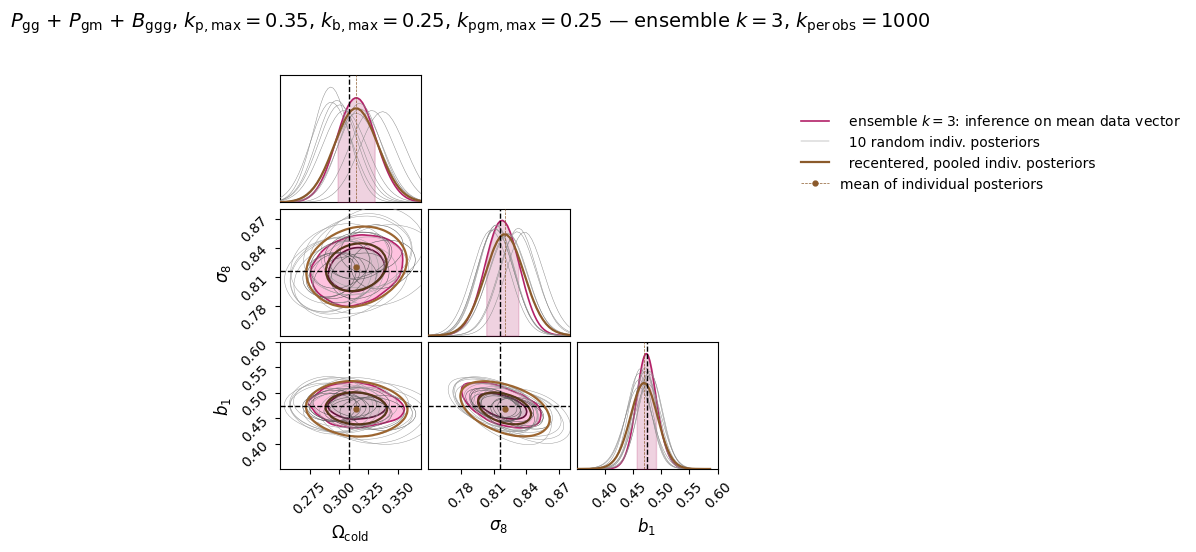

In [28]:
# Final full-combo ensemble k=3 A1 with k_per_obs=1000 (1000 CV-mean draws per member)
STATS_FULL, MASK_FULL, COLOR_FULL = STATS_FULL_NEWFID, MASK_FULL_NEWFID, COLOR_FULL_NEWFID
STATISTICS_ROW = list(STATS_FULL)
skey = _stats_save_key(STATS_FULL)
k_per_obs = 1000
n_ensemble_draws = k_per_obs * N_ENSEMBLE_K  # 1000 from each member
print(
    get_stat_label_short(STATS_FULL), MASK_FULL,
    f"ensemble k={N_ENSEMBLE_K}, k_per_obs={k_per_obs}, n_ensemble_draws={n_ensemble_draws}"
)
plot_a1_ensemble_variant(
    tag_masks_row=MASK_FULL,
    n_train=n_train_fid,
    color_mean=COLOR_FULL,
    param_names=PARAM_NAMES_ZOOM,
    theta_obs_true=THETA_SHOW,
    extents=EXTENTS_A,
    figsize=FIGSIZE_CORNER,
    title=_newfid_title(
        STATS_FULL, MASK_FULL,
        rf"ensemble $k={N_ENSEMBLE_K}$, $k_{{\mathrm{{per\,obs}}}}={k_per_obs}$",
    ),
    save_name=f"figA1_{skey}_newfid_zoom_ensK{N_ENSEMBLE_K}_k{k_per_obs}",
    plot_indiv_means=False,
    mark_mean_of_means=True,
    k_members=N_ENSEMBLE_K,
    n_ensemble_draws=n_ensemble_draws,
    k_per_obs=k_per_obs,
)


## Full stats combo — ensemble mean-inf vs $n_\mathrm{draws}$

Equal-weight $k=3$ CV-mean mixture for **$P_\mathrm{gg}+B_\mathrm{ggg}+P_\mathrm{gm}$**, overlaying contours built from different total numbers of posterior draws ($n_\mathrm{total}=1000,\,3000,\,10000,\,30000$). Each member chain has 10000 samples, so $30000$ uses the full equal-weight pool.


/tmp/ipykernel_2156086/3996123206.py:148: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


n_draws=10000: mix shape = (10000, 3)
n_draws=100000: mix shape = (100000, 3)


Saved: /home/kstoreyf/muchisimocks/figures/2026-09-08_mean_inf_checks/figA1_pk_bispec_pgm_newfid_ensK3_meaninf_vs_ndraws.png


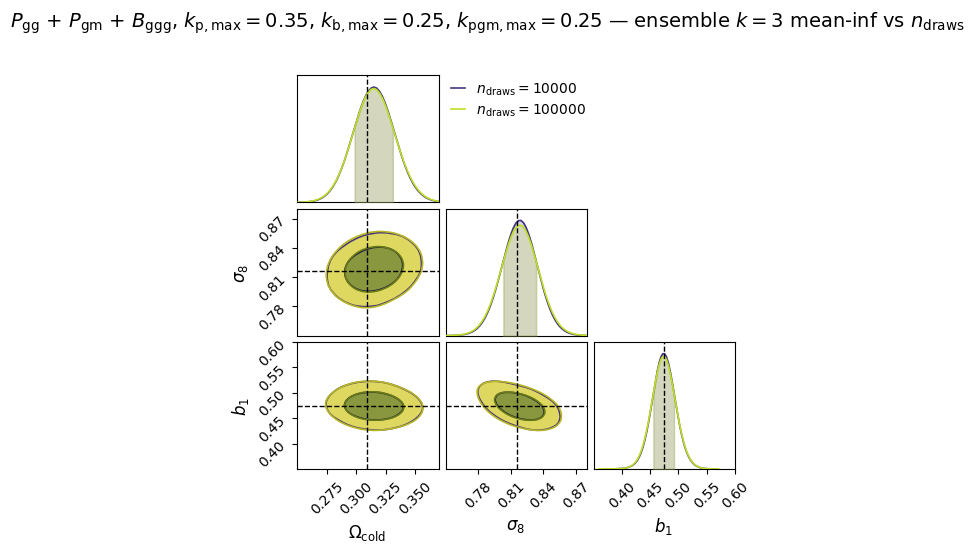

In [10]:
# Ensemble k=3 CV-mean-inf: overlay contours for different n_total draws
from ensemble_kmax_utils import load_ensemble_member_samples

STATS_FULL, MASK_FULL, COLOR_FULL = STATS_FULL_NEWFID, MASK_FULL_NEWFID, COLOR_FULL_NEWFID
STATISTICS_ROW = list(STATS_FULL)
skey = _stats_save_key(STATS_FULL)
#N_DRAWS_ARR = [1000, 3000, 10000, 30000, 100000]
N_DRAWS_ARR = [10000, 100000]
draw_colors = sequential_colors(N_DRAWS_ARR)

tag_inf_top = build_tag_inf(MASK_FULL, n_train_fid)
names_rp = list(np.loadtxt(dir_sbi / f"sbi{tag_inf_top}" / "param_names.txt", dtype=str))
names_plot = list(PARAM_NAMES_ZOOM)

samples_list, colors, labels = [], [], []
for n_tot in N_DRAWS_ARR:
    mix_rp, missing = load_ensemble_member_samples(
        list(STATISTICS_ROW),
        MASK_FULL,
        test_mode="cvmean",
        k_members=N_ENSEMBLE_K,
        n_total=n_tot,
    )
    if mix_rp is None:
        print(f"n_draws={n_tot}: unavailable")
        for m in missing:
            print(f"  {m}")
        continue
    mix_u, names_u = utils_inference.unreparameterize_theta(mix_rp, names_rp, strict=False)
    names_u = list(names_u)
    i_sel = [names_u.index(pn) for pn in names_plot]
    mix_zoom = mix_u[:, i_sel]
    print(f"n_draws={n_tot}: mix shape = {mix_zoom.shape}")
    samples_list.append((mix_zoom, names_plot))
    colors.append(draw_colors[n_tot])
    labels.append(rf"$n_{{\mathrm{{draws}}}}={n_tot}$")

if not samples_list:
    print("Nothing to plot.")
else:
    n_c = len(samples_list)
    fig = plotter.plot_contours_inf(
        param_names=names_plot,
        idx_obs=idx_obs,
        theta_obs_true=THETA_SHOW,
        inf_methods=["sbi"] * n_c,
        tags_inf=[tag_inf_top] * n_c,
        tags_test=[None] * n_c,
        colors=colors,
        labels=labels,
        shades=[True] * n_c,
        linewidths=[LW_MEAN] * n_c,
        fontsize_legend=FONTSIZE_LEGEND,
        legend_location=(0, 1),
        legend_loc="upper left",
        loc_legend=None,
        title=_newfid_title(
            STATS_FULL, MASK_FULL,
            rf"ensemble $k={N_ENSEMBLE_K}$ mean-inf vs $n_{{\mathrm{{draws}}}}$",
        ),
        extents=EXTENTS_A,
        figsize=FIGSIZE_CORNER,
        unreparameterize=True,
        samples_list=samples_list,
        show=False,
    )
    if fig is not None:
        save_figure(fig, f"figA1_{skey}_newfid_ensK{N_ENSEMBLE_K}_meaninf_vs_ndraws")
    plt.show()
